# ESTIMACIÓN PROBABILÍSTICA SEMANAL DE EVENTOS SÍSMICOS
 ## Objetivos
 Determinar la eficacia de una red neuronal para el pronóstico semanal de eventos sísmicos en el Perú.

## Carga de datos

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display

carpeta_datos = Path(r"C:\Users\user\curso-ia-web\Grupo2_UPC_ML\datos IGP")
datos_sismicos = {
    "historico": pd.read_excel(carpeta_datos / "datos-sismicos_Historico.xlsx"),
    "instrumental": pd.read_excel(carpeta_datos / "datos-sismicos_Instrumental.xlsx"),
}

for nombre, df in datos_sismicos.items():
    print(f"{nombre}: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    display(df.head())


historico: 1,098 filas x 6 columnas


,fecha UTC,hora UTC,latitud (º),longitud (º),profundidad (km),magnitud (M)
0,1552-07-02,10:30:00.00,-16.6,-71.3,30,-
1,1555-11-15,00:00:00.00,-11.9,-77.6,30,-
2,1568-04-04,00:00:00.00,-12.3,-77.7,30,-
3,1582-01-22,16:30:00.00,-16.6,-71.6,30,7.5
4,1582-08-15,00:00:00.00,-12.2,-77.6,30,-


instrumental: 25,758 filas x 6 columnas


,fecha UTC,hora UTC,latitud (º),longitud (º),profundidad (km),magnitud (M)
0,1960-01-13,15:40:34.00,-16.145,-72.144,60,7.5
1,1960-01-15,09:30:24.00,-15.000,-75.000,70,7.0
2,1960-01-17,02:57:58.00,-14.500,-74.500,150,6.4
3,1960-01-23,03:37:32.00,-12.500,-68.500,300,5.8
4,1960-01-30,05:07:24.00,-5.500,-77.500,100,5.7


## EDA y limpieza
 Se revisan estructura, faltantes y duplicados. La limpieza genera copias y convierte los marcadores de ausencia, variables numéricas y fechas.

In [2]:
import pandas as pd

# EDA inicial de los catalogos cargados
for nombre, df in datos_sismicos.items():
    guiones = df.astype("string").eq("-").sum()
    print(f"\n{nombre.upper()}: {len(df):,} filas x {len(df.columns)} columnas")
    print("Columnas:", list(df.columns))
    print("Tipos:", df.dtypes.astype(str).to_dict())
    print("Nulos explicitos:", int(df.isna().sum().sum()), "| Marcadores '-':", int(guiones.sum()))
    print("Duplicados exactos:", int(df.duplicated().sum()))
    for col in df.columns:
        if any(k in str(col).lower() for k in ("latitud", "longitud", "profundidad", "magnitud")):
            valores = pd.to_numeric(df[col].replace("-", pd.NA), errors="coerce")
            if valores.notna().any():
                print(f"  {col}: n={valores.notna().sum():,}, min={valores.min()}, mediana={valores.median()}, max={valores.max()}")

# Limpiar copias y conservar los DataFrames originales en datos_sismicos.
def limpiar_catalogo(original):
    df = original.copy()
    renombres = {}
    for col in df.columns:
        nombre_col = str(col).strip().lower()
        if "fecha" in nombre_col:
            renombres[col] = "fecha_utc"
        elif "hora" in nombre_col:
            renombres[col] = "hora_utc"
        elif "latitud" in nombre_col:
            renombres[col] = "latitud"
        elif "longitud" in nombre_col:
            renombres[col] = "longitud"
        elif "profundidad" in nombre_col:
            renombres[col] = "profundidad_km"
        elif "magnitud" in nombre_col:
            renombres[col] = "magnitud_m"
    df = df.rename(columns=renombres)
    for col in df.select_dtypes(include="object"):
        df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)
        df[col] = df[col].replace({"": pd.NA, "-": pd.NA, "?": pd.NA, "NA": pd.NA, "N/A": pd.NA})
    for col in ("latitud", "longitud", "profundidad_km", "magnitud_m"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    fechas_invalidas = 0
    if "fecha_utc" in df.columns:
        df["fecha_utc"] = pd.to_datetime(df["fecha_utc"], errors="coerce")
        fechas_invalidas = int(df["fecha_utc"].isna().sum())
    duplicados = int(df.duplicated().sum())
    df = df.drop_duplicates().reset_index(drop=True)
    return df, duplicados, fechas_invalidas

datos_limpios = {}
resumen_limpieza = []
for nombre, original in datos_sismicos.items():
    limpio, duplicados, fechas_invalidas = limpiar_catalogo(original)
    datos_limpios[nombre] = limpio
    faltantes = limpio.isna().sum()
    resumen_limpieza.append({
        "catalogo": nombre,
        "filas originales": len(original),
        "filas limpias": len(limpio),
        "duplicados retirados": duplicados,
        "fechas faltantes/invalidas": fechas_invalidas,
        "faltantes de profundidad": int(faltantes.get("profundidad_km", 0)),
        "faltantes de magnitud": int(faltantes.get("magnitud_m", 0)),
    })
print("\nRESUMEN DE LIMPIEZA")
print(pd.DataFrame(resumen_limpieza).set_index("catalogo").to_string())

# Tres insights calculados sobre los datos limpios
historico = datos_limpios["historico"]
instrumental = datos_limpios["instrumental"]
ratio = len(instrumental) / max(len(historico), 1)
print(f"\nINSIGHT 1 - Volumen: {len(historico):,} registros historicos y {len(instrumental):,} instrumentales ({ratio:.1f} veces mas instrumentales).")
fechas = {}
for nombre, df in datos_limpios.items():
    if "fecha_utc" in df.columns:
        serie = df["fecha_utc"].dropna()
        if not serie.empty:
            fechas[nombre] = (serie.min(), serie.max())
if fechas:
    detalle = "; ".join(f"{n}: {inicio.date()} a {fin.date()}" for n, (inicio, fin) in fechas.items())
    print(f"INSIGHT 2 - Cobertura observada: {detalle}.")
    if "historico" in fechas and "instrumental" in fechas:
        dias = (fechas["instrumental"][0] - fechas["historico"][1]).days
        print(f"  Hay {dias} dias entre el ultimo registro historico y el primero instrumental; esto describe los catalogos y no prueba ausencia de sismos.")
completitud = []
for nombre, df in datos_limpios.items():
    if "magnitud_m" in df.columns:
        disponible = int(df["magnitud_m"].notna().sum())
        completitud.append(f"{nombre}: {disponible:,}/{len(df):,} con magnitud ({100*disponible/max(len(df),1):.1f}%)")
print("INSIGHT 3 - Disponibilidad de magnitud M: " + "; ".join(completitud) + ".")
print("\nNo se imputaron faltantes; los DataFrames fuente permanecen en datos_sismicos.")



HISTORICO: 1,098 filas x 6 columnas
Columnas: ['fecha UTC', 'hora UTC', 'latitud (º)', 'longitud (º)', 'profundidad (km)', 'magnitud (M)']
Tipos: {'fecha UTC': 'str', 'hora UTC': 'str', 'latitud (º)': 'float64', 'longitud (º)': 'float64', 'profundidad (km)': 'str', 'magnitud (M)': 'str'}
Nulos explicitos: 0 | Marcadores '-': 1145
Duplicados exactos: 0
  latitud (º): n=1,098, min=-20.05, mediana=-12.2, max=-1.75
  longitud (º): n=1,098, min=-84.0, mediana=-76.2, max=-68.0
  profundidad (km): n=1,039, min=5.0, mediana=40.0, max=700.0
  magnitud (M): n=12, min=6.8, mediana=8.1, max=8.8



INSTRUMENTAL: 25,758 filas x 6 columnas
Columnas: ['fecha UTC', 'hora UTC', 'latitud (º)', 'longitud (º)', 'profundidad (km)', 'magnitud (M)']
Tipos: {'fecha UTC': 'str', 'hora UTC': 'str', 'latitud (º)': 'float64', 'longitud (º)': 'float64', 'profundidad (km)': 'int64', 'magnitud (M)': 'float64'}
Nulos explicitos: 0 | Marcadores '-': 0
Duplicados exactos: 0
  latitud (º): n=25,758, min=-20.31, mediana=-11.7958, max=-1.07
  longitud (º): n=25,758, min=-82.8937, mediana=-75.72970000000001, max=-67.64
  profundidad (km): n=25,758, min=5, mediana=48.0, max=743
  magnitud (M): n=25,758, min=3.0, mediana=4.6, max=8.4


C:\Users\user\AppData\Local\Temp\ipykernel_69044\949942000.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):
C:\Users\user\AppData\Local\Temp\ipykernel_69044\949942000.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-


RESUMEN DE LIMPIEZA
              filas originales  filas limpias  duplicados retirados  fechas faltantes/invalidas  faltantes de profundidad  faltantes de magnitud
catalogo                                                                                                                                        
historico                 1098           1098                     0                           0                        59                   1086
instrumental             25758          25758                     0                           0                         0                      0

INSIGHT 1 - Volumen: 1,098 registros historicos y 25,758 instrumentales (23.5 veces mas instrumentales).
INSIGHT 2 - Cobertura observada: historico: 1552-07-02 a 1959-12-02; instrumental: 1960-01-13 a 2026-10-01.
  Hay 42 dias entre el ultimo registro historico y el primero instrumental; esto describe los catalogos y no prueba ausencia de sismos.
INSIGHT 3 - Disponibilidad de magnitud M: histori

## PCA y Kernel PCA
Se analizan latitud, longitud, profundidad y magnitud M. Se usa el cat?logo instrumental porque el hist?rico carece de magnitud en casi todos sus registros. Las variables se estandarizan. Kernel PCA usa una muestra fija de 1,500 eventos por el costo cuadr?tico de su matriz de similitud. Los paneles comparan kernels lineal, RBF, polin?mico y sigmoide; el color representa magnitud.

Catalogo usado: instrumental; filas completas: 25,758 de 25,758.
Variables: localizacion (latitud, longitud), profundidad y magnitud M.



PCA clasico (datos completos): varianza explicada por PC1-PC2 = 74.2%.
Trustworthiness (mas cercano a 1 conserva mejor las vecindades locales):
  PCA clasico: 0.910
  Kernel PCA linear: 0.910
  Kernel PCA rbf: 0.860
  Kernel PCA poly: 0.906
  Kernel PCA sigmoid: 0.902

Kernel PCA se ajusto a la misma muestra de eventos; gamma=0.25 para RBF/sigmoide; gamma=0.0625 y degree=2 para polinomico; coef0=1.
Los ejes de cada panel se escalaron por separado solo para comparar la forma; no son unidades fisicas ni distancias directamente comparables.


<Figure size 1600x1000 with 7 Axes>

<Figure size 1200x450 with 2 Axes>

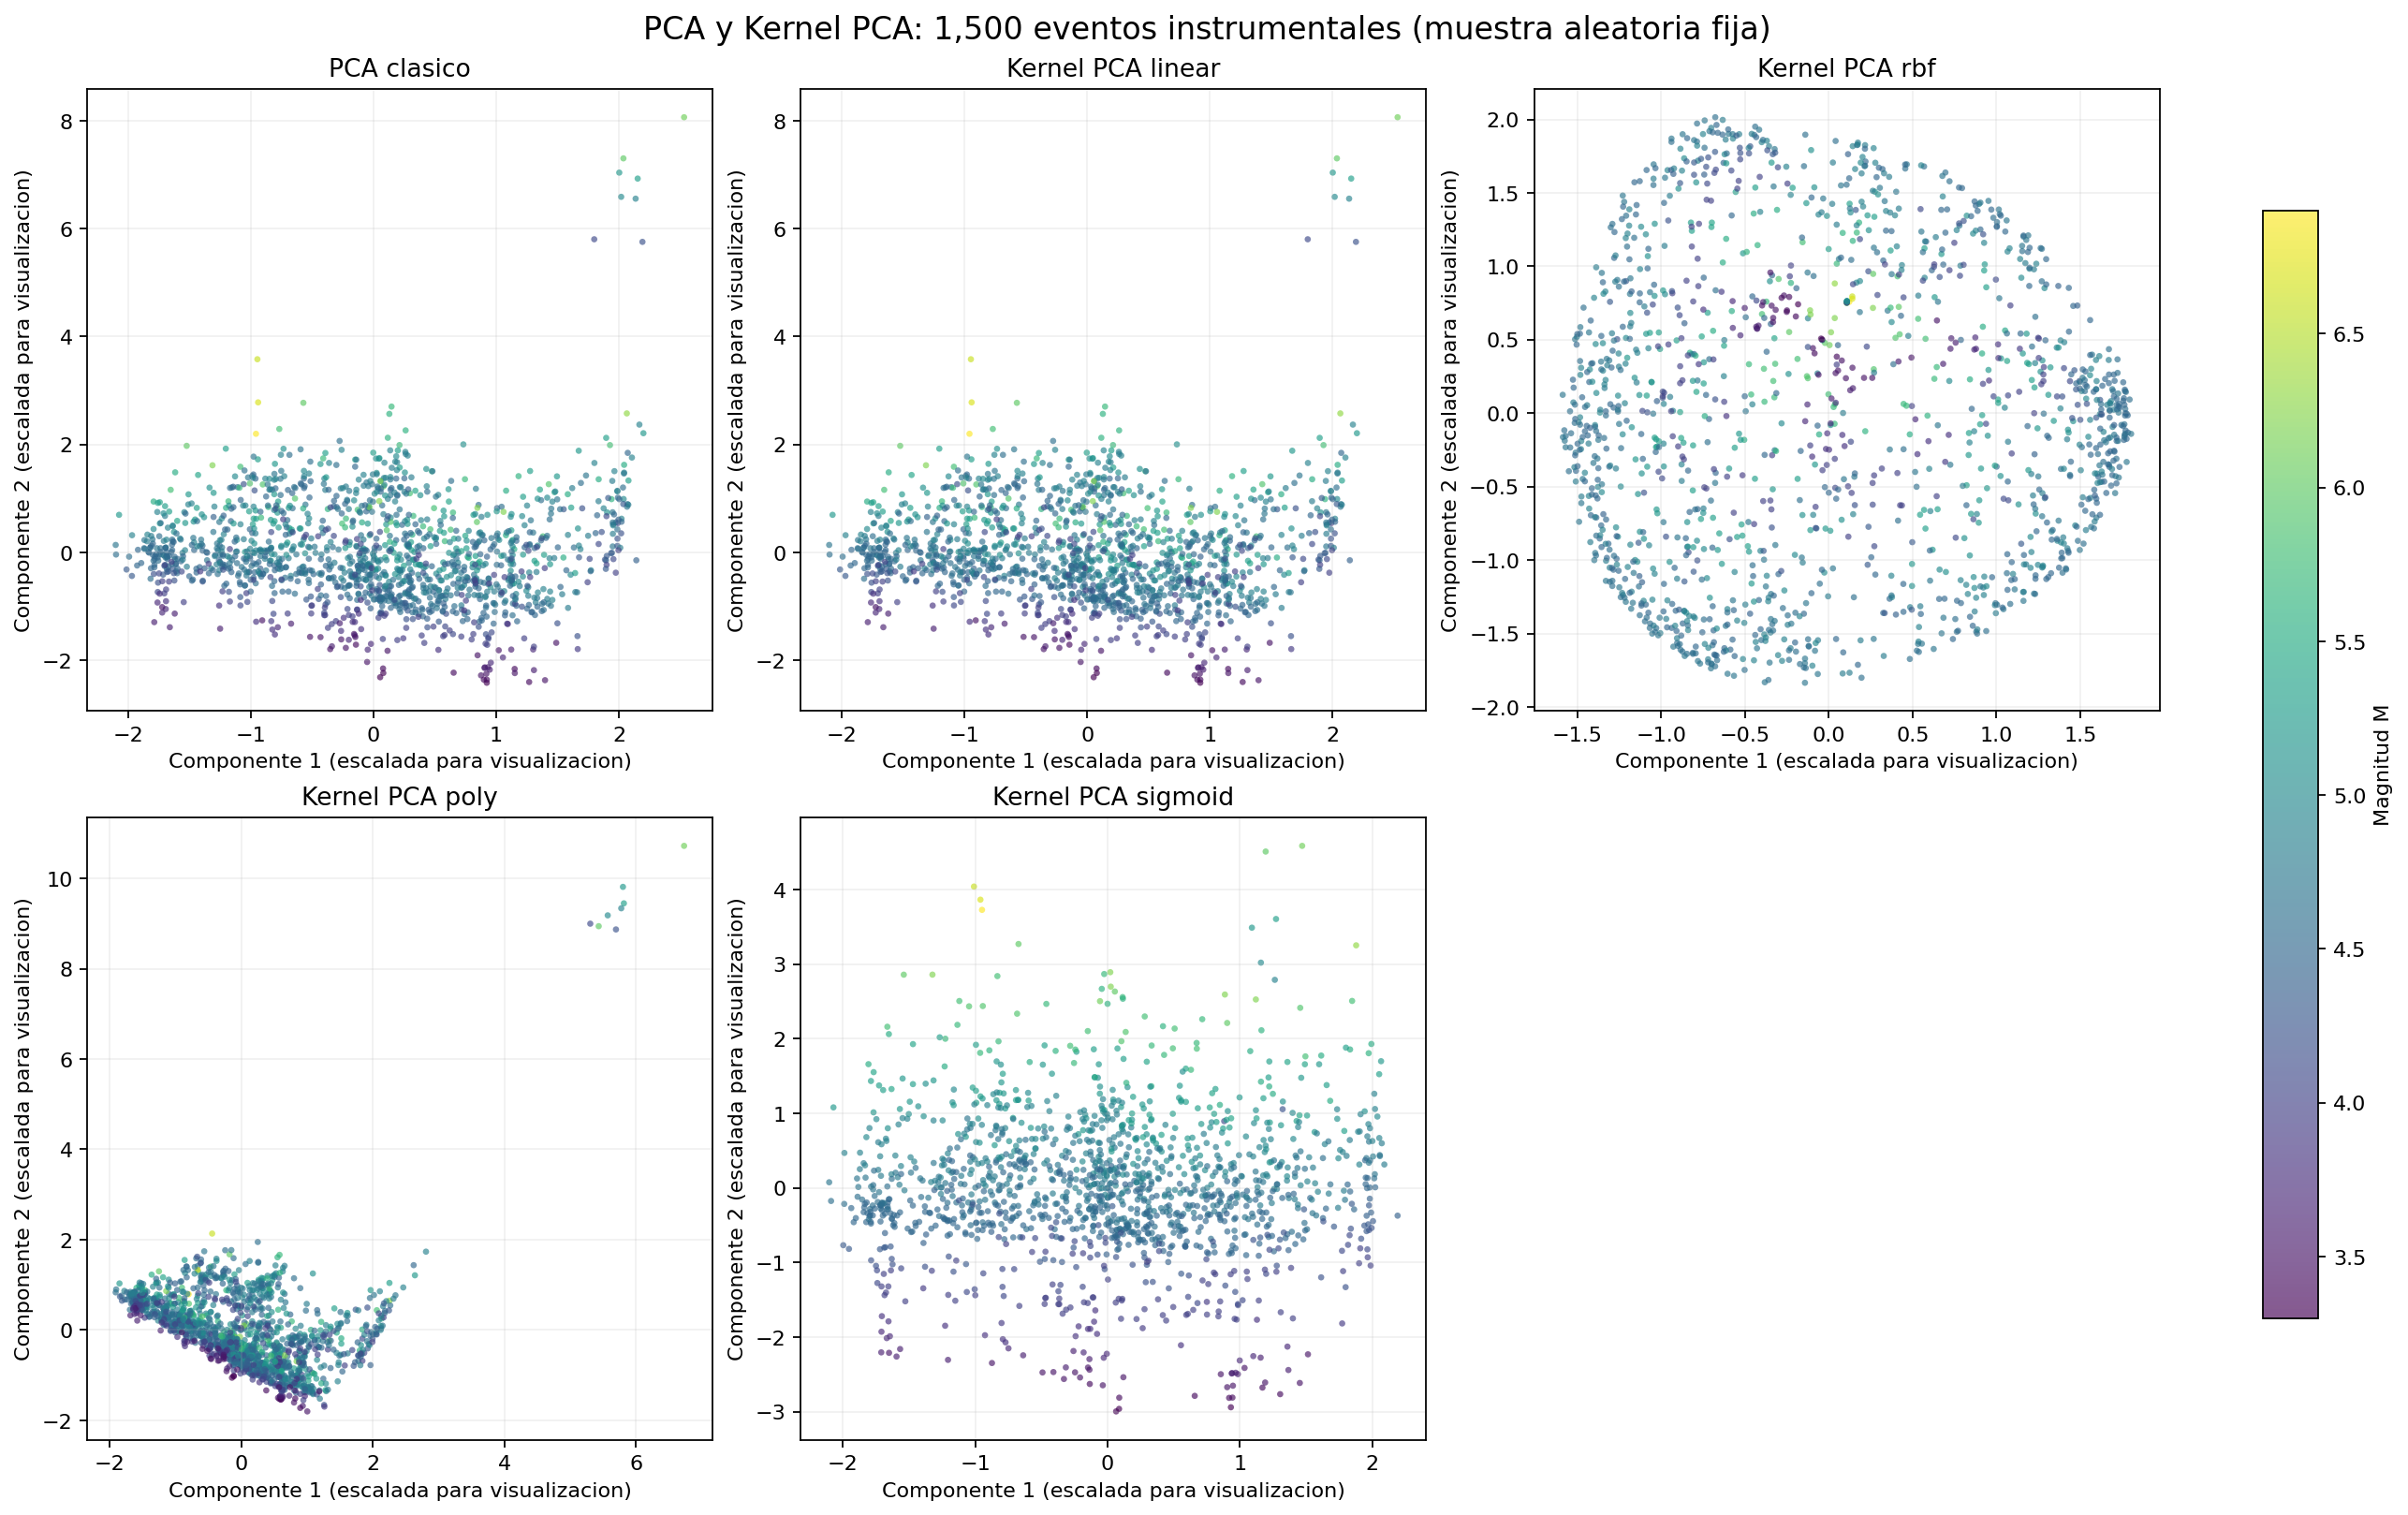

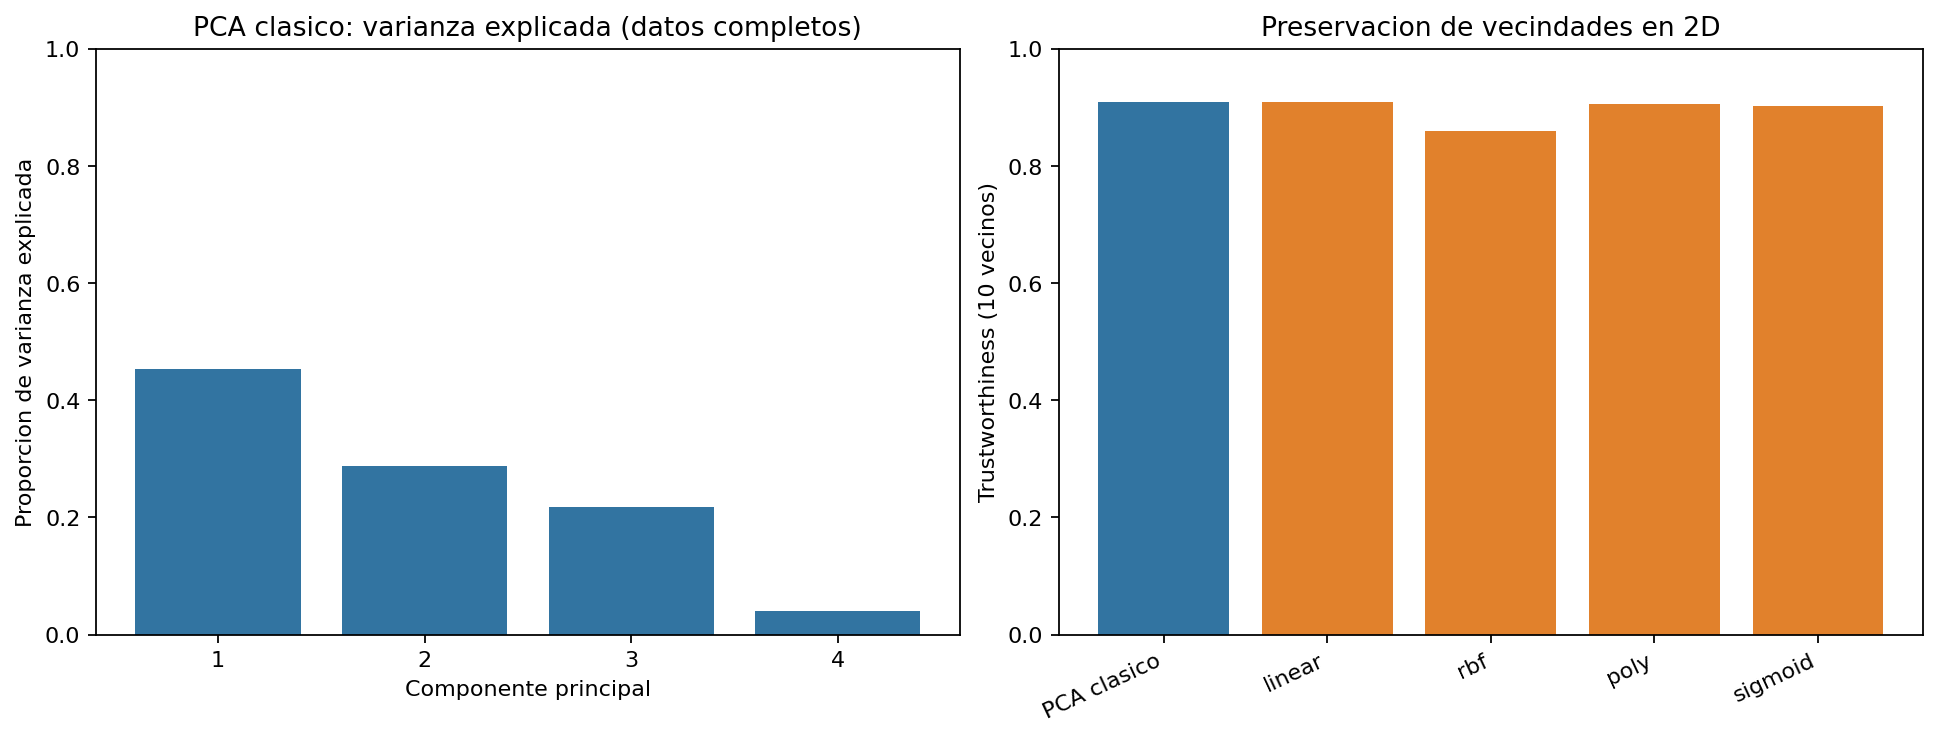

In [3]:
import gc
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import trustworthiness
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display

# El historico solo tiene magnitud para 12 de 1,098 eventos. Para usar las cuatro
# variables sin imputar, PCA se ajusta al catalogo instrumental completo.
df_pca = datos_limpios["instrumental"].copy()
variables = ["latitud", "longitud", "profundidad_km", "magnitud_m"]
X_df = df_pca[variables].dropna()
print(f"Catalogo usado: instrumental; filas completas: {len(X_df):,} de {len(df_pca):,}.")
print("Variables: localizacion (latitud, longitud), profundidad y magnitud M.")

# Estandarizar es necesario porque las variables tienen unidades y escalas distintas.
escalador_pca = StandardScaler()
X_estandar = escalador_pca.fit_transform(X_df)
pca_completo = PCA(n_components=4, random_state=42).fit(X_estandar)

# Kernel PCA requiere una matriz de similitud O(n^2); usar la misma muestra reproducible
# para comparar los kernels y mostrar graficos legibles.
n_muestra = min(1500, len(X_estandar))
rng = np.random.default_rng(42)
indices_muestra = np.sort(rng.choice(len(X_estandar), size=n_muestra, replace=False))
X_muestra = X_estandar[indices_muestra]
magnitud_color = X_df["magnitud_m"].to_numpy()[indices_muestra]
pca_muestra = PCA(n_components=2, random_state=42)
coord_pca = pca_muestra.fit_transform(X_muestra)

embeddings = {"PCA clasico": coord_pca}
metricas = [("PCA clasico", trustworthiness(X_muestra, coord_pca, n_neighbors=10))]
parametros_kernel = {"gamma": 1 / len(variables), "gamma_poly": 1 / (4 * len(variables)), "degree_poly": 2, "coef0": 1}
for kernel in ("linear", "rbf", "poly", "sigmoid"):
    modelo = KernelPCA(
        n_components=2, kernel=kernel, gamma=parametros_kernel["gamma_poly"] if kernel == "poly" else parametros_kernel["gamma"],
        degree=parametros_kernel["degree_poly"] if kernel == "poly" else 3, coef0=parametros_kernel["coef0"],
        eigen_solver="arpack", random_state=42,
    )
    coord = modelo.fit_transform(X_muestra)
    embeddings[f"Kernel PCA {kernel}"] = coord
    metricas.append((f"Kernel PCA {kernel}", trustworthiness(X_muestra, coord, n_neighbors=10)))
    del modelo, coord
    gc.collect()

# Panel: misma muestra y escala de color por magnitud para todos los metodos.
def escalar_para_grafico(coordenadas):
    centradas = coordenadas - coordenadas.mean(axis=0)
    dispersion = coordenadas.std(axis=0)
    dispersion[dispersion == 0] = 1
    return centradas / dispersion

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
for ax, (nombre, coordenadas) in zip(axes.flat, embeddings.items()):
    puntos = escalar_para_grafico(coordenadas)
    sc = ax.scatter(puntos[:, 0], puntos[:, 1], c=magnitud_color, cmap="viridis", s=9, alpha=0.65, linewidths=0)
    ax.set_title(nombre)
    ax.set_xlabel("Componente 1 (escalada para visualizacion)")
    ax.set_ylabel("Componente 2 (escalada para visualizacion)")
    ax.grid(alpha=0.18)
axes.flat[-1].axis("off")
fig.colorbar(sc, ax=list(axes.flat[:-1]), label="Magnitud M", shrink=0.82)
fig.suptitle(f"PCA y Kernel PCA: {n_muestra:,} eventos instrumentales (muestra aleatoria fija)", fontsize=15)

# Diagnosticos: varianza explicada por PCA clasico sobre todos los eventos y
# trustworthiness local de cada proyeccion de la muestra.
fig_diag, (ax_var, ax_trust) = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
componentes = np.arange(1, 5)
ax_var.bar(componentes, pca_completo.explained_variance_ratio_, color="#3274a1")
ax_var.set_xticks(componentes)
ax_var.set_xlabel("Componente principal")
ax_var.set_ylabel("Proporcion de varianza explicada")
ax_var.set_title("PCA clasico: varianza explicada (datos completos)")
ax_var.set_ylim(0, 1)
nombres_metricas, valores_metricas = zip(*metricas)
ax_trust.bar(range(len(valores_metricas)), valores_metricas, color=["#3274a1"] + ["#e1812c"] * (len(valores_metricas)-1))
ax_trust.set_xticks(range(len(nombres_metricas)), [x.replace("Kernel PCA ", "") for x in nombres_metricas], rotation=25, ha="right")
ax_trust.set_ylim(0, 1)
ax_trust.set_ylabel("Trustworthiness (10 vecinos)")
ax_trust.set_title("Preservacion de vecindades en 2D")
figuras_dir = Path(r"C:\Users\user\curso-ia-web\Grupo2_UPC_ML\figuras")
figuras_dir.mkdir(exist_ok=True)
fig.savefig(figuras_dir / "T2_PCA_KernelPCA_comparacion.png", dpi=160, bbox_inches="tight")
fig_diag.savefig(figuras_dir / "T2_PCA_diagnosticos.png", dpi=160, bbox_inches="tight")
print(f"\nPCA clasico (datos completos): varianza explicada por PC1-PC2 = {pca_completo.explained_variance_ratio_[:2].sum():.1%}.")
print("Trustworthiness (mas cercano a 1 conserva mejor las vecindades locales):")
for nombre, valor in metricas:
    print(f"  {nombre}: {valor:.3f}")
print("\nKernel PCA se ajusto a la misma muestra de eventos; gamma=0.25 para RBF/sigmoide; gamma=0.0625 y degree=2 para polinomico; coef0=1.")
print("Los ejes de cada panel se escalaron por separado solo para comparar la forma; no son unidades fisicas ni distancias directamente comparables.")
display(fig)
display(fig_diag)
plt.close(fig)
plt.close(fig_diag)


## Visualizacion geoespacial y patrones temporales
Mapa de densidad en coordenadas longitud/latitud, cambios espaciales por periodos y conteos por fecha. Se marca 2026 como periodo parcial; los conteos anuales no se interpretan directamente como cambios de actividad sismica.

Eventos incluidos: 25,758; fechas: 1960-01-13 a 2026-10-01.
Eventos M >= 6: 308 (1.20%).
Pico anual completo: 2014 con 1,023 eventos; 2026 lleva 702 eventos hasta el 1 de octubre.
Promedio por periodo: 1960-1979: 106.4 eventos/ano; 1980-1999: 322.4 eventos/ano; 2000-2019: 624.5 eventos/ano; 2020-2025 completos: 664.7 eventos/ano.
Promedio mensual minimo: 9 (28.1); maximo: 10 (34.9) eventos/ano.
Celda geografica de 1 grado con mas eventos: latitud [-15,-14), longitud [-77,-76): 817.
Las tendencias de conteo describen el catalogo; el aumento puede reflejar cambios de cobertura/registro y no prueba por si solo un aumento de la actividad sismica. El mapa usa coordenadas lon/lat, sin limites administrativos ni costa de fondo.


<Figure size 900x1000 with 2 Axes>

<Figure size 1200x800 with 2 Axes>

<Figure size 1200x1100 with 5 Axes>

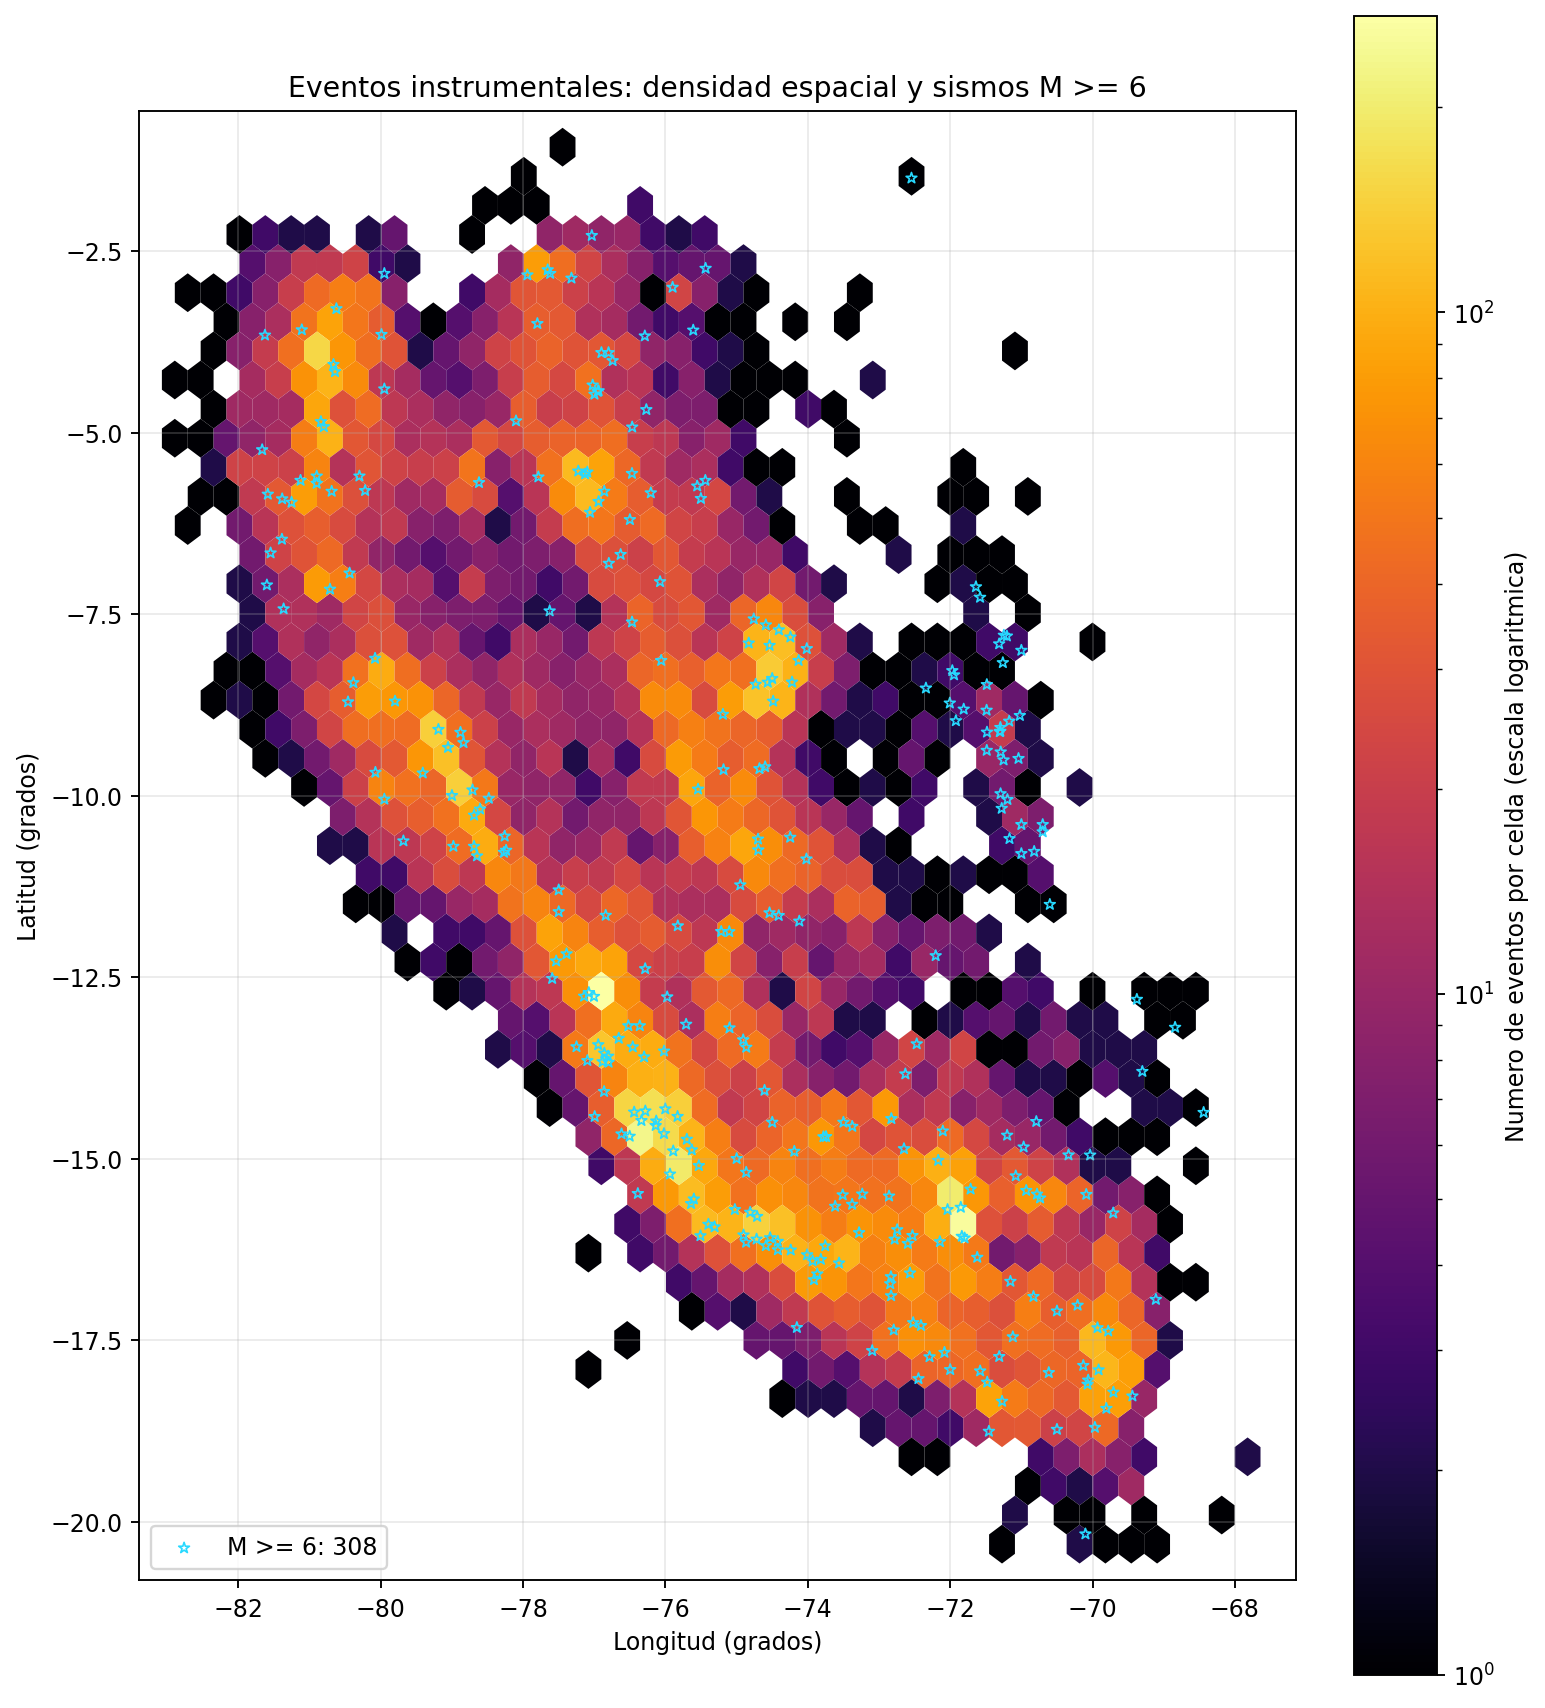

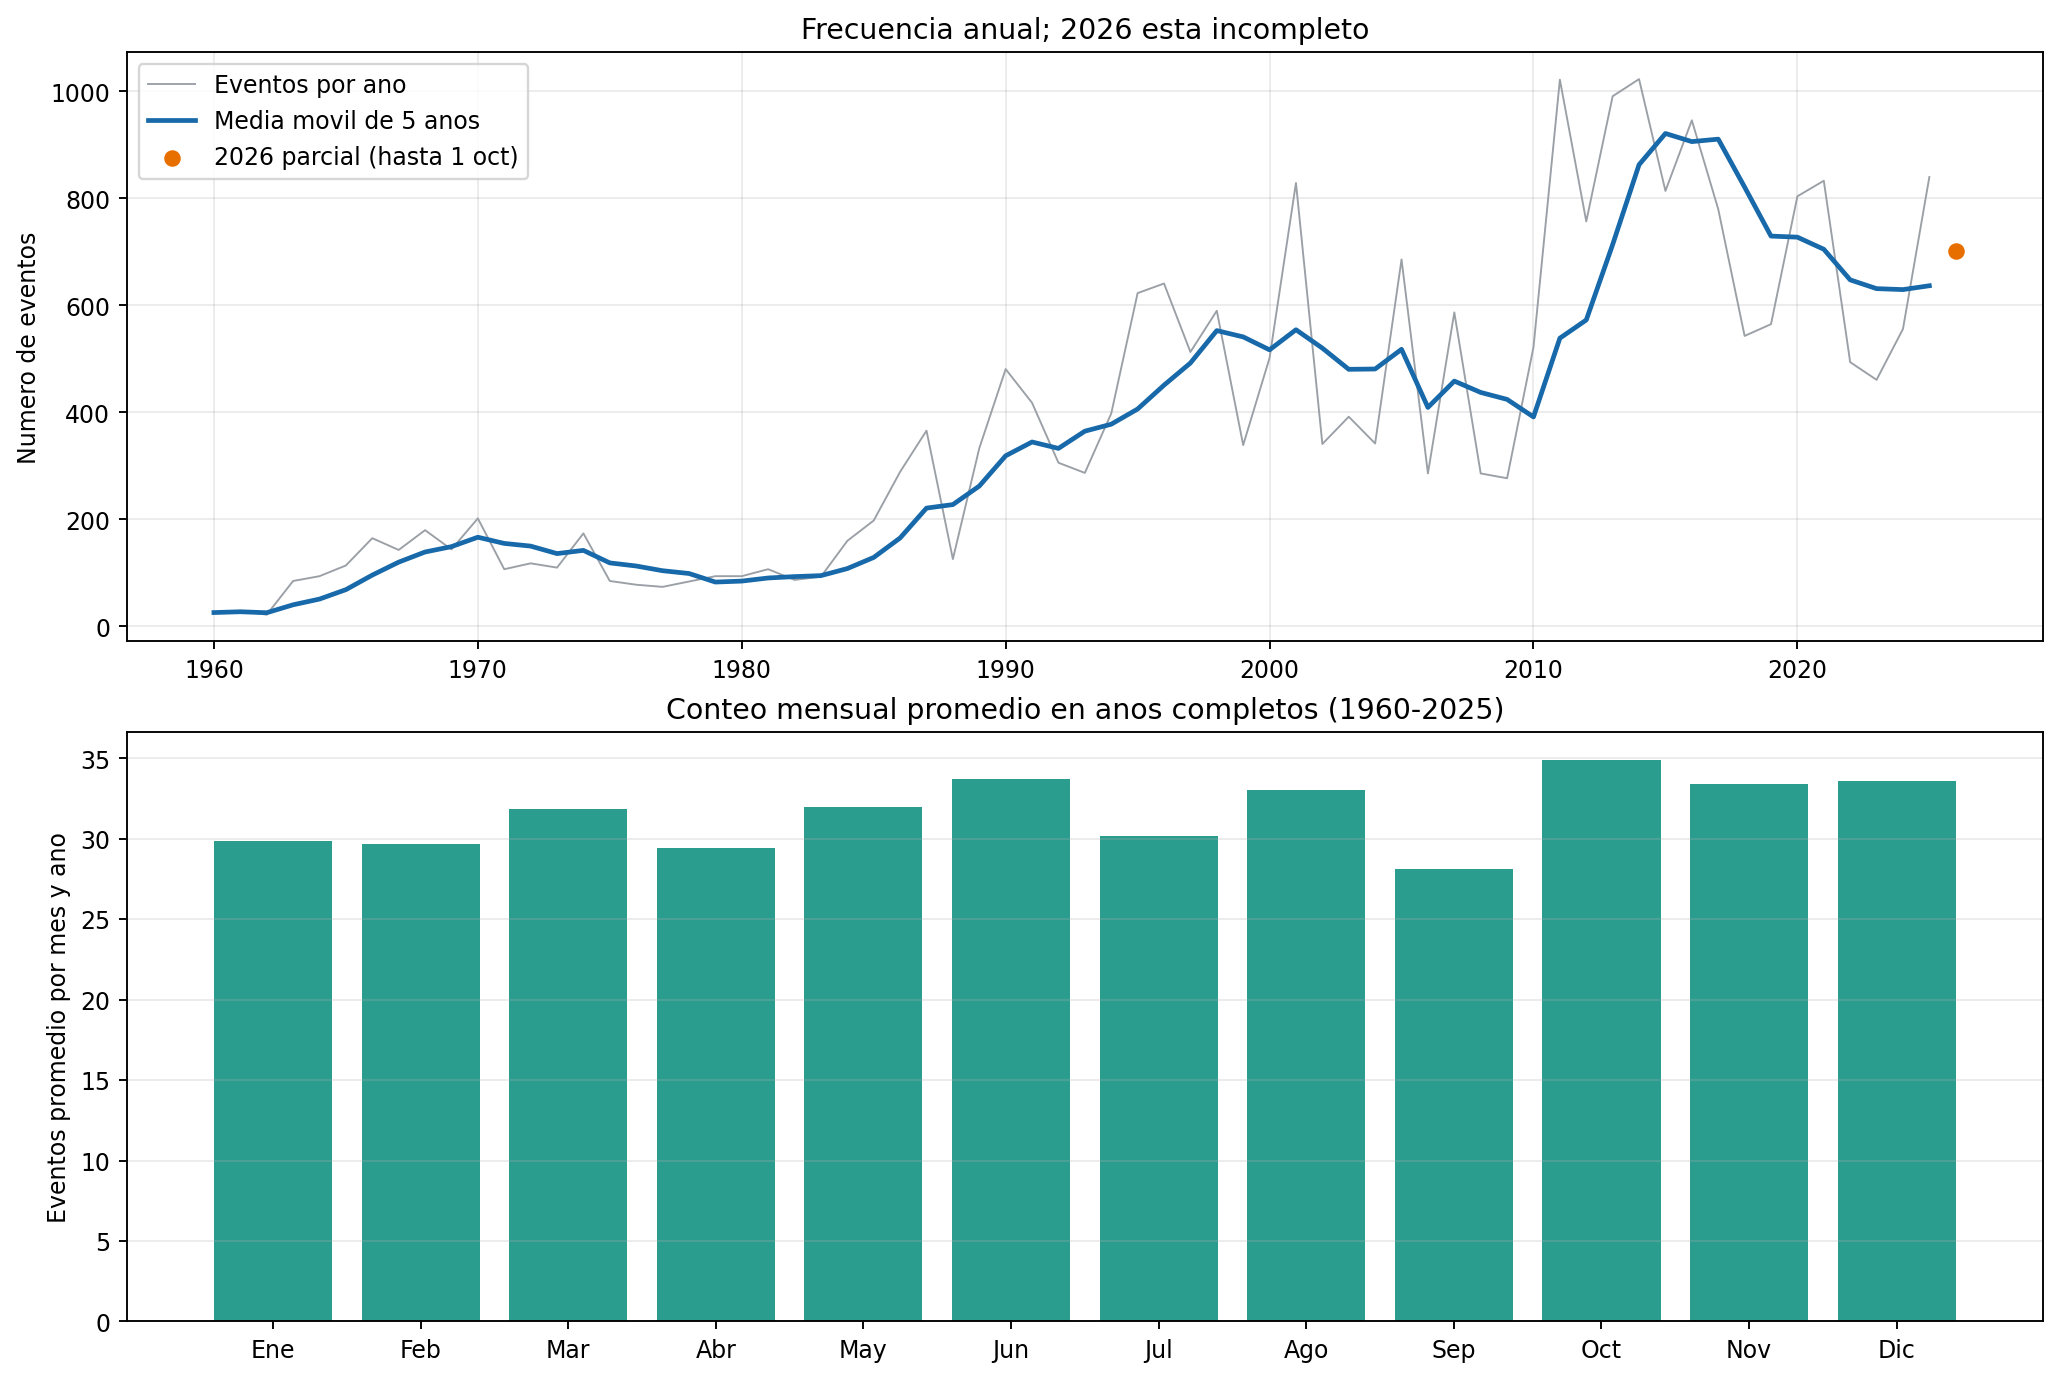

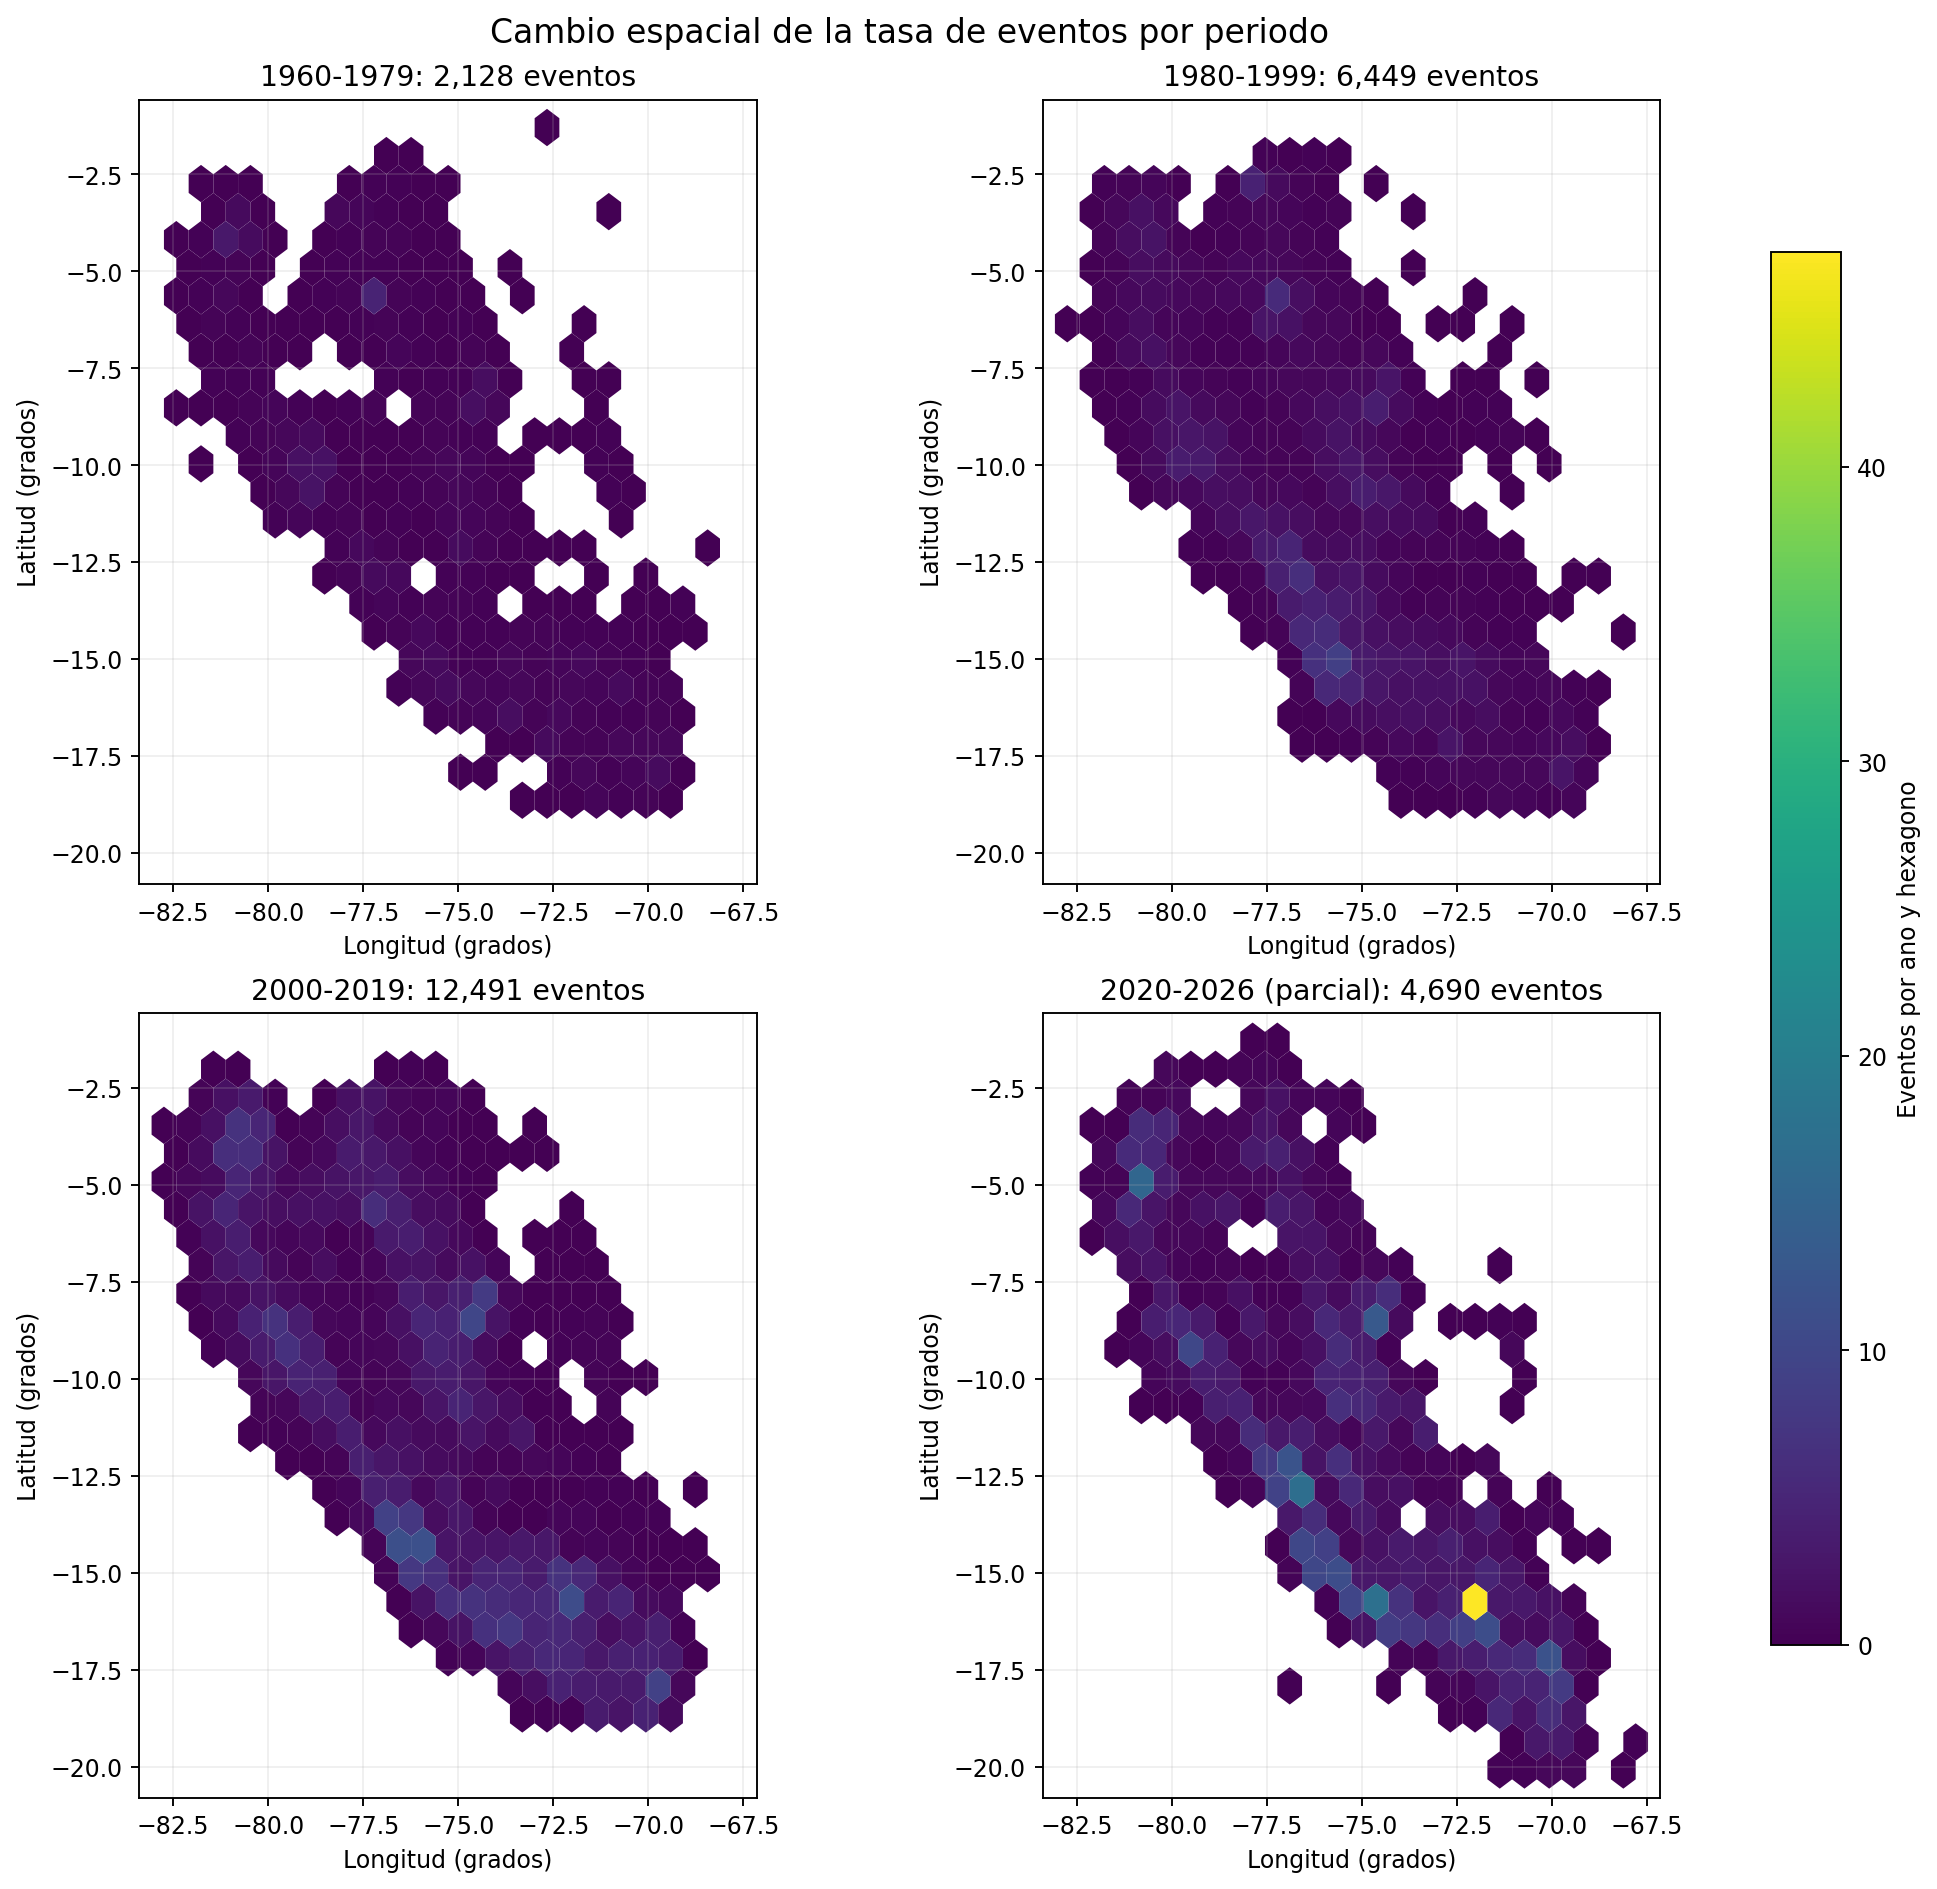

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display

# Usar las coordenadas y fechas del catalogo instrumental limpio.
eventos = datos_limpios["instrumental"].dropna(subset=["fecha_utc", "latitud", "longitud", "magnitud_m"]).copy()
eventos["anio"] = eventos["fecha_utc"].dt.year
eventos["mes"] = eventos["fecha_utc"].dt.month
lat = eventos["latitud"].to_numpy()
lon = eventos["longitud"].to_numpy()
lat_media = float(np.mean(lat))
aspecto_geo = 1 / np.cos(np.deg2rad(lat_media))

# Mapa de densidad de todos los eventos; estrellas para M >= 6.
fig_geo, ax = plt.subplots(figsize=(9, 10), constrained_layout=True)
hb = ax.hexbin(lon, lat, gridsize=42, mincnt=1, bins="log", cmap="inferno", linewidths=0)
fuertes = eventos["magnitud_m"] >= 6
ax.scatter(eventos.loc[fuertes, "longitud"], eventos.loc[fuertes, "latitud"], marker="*", s=23,
           facecolors="none", edgecolors="#27d9ff", linewidths=0.7, label=f"M >= 6: {int(fuertes.sum())}")
ax.set_xlim(lon.min()-0.5, lon.max()+0.5)
ax.set_ylim(lat.min()-0.5, lat.max()+0.5)
ax.set_aspect(aspecto_geo)
ax.set_xlabel("Longitud (grados)")
ax.set_ylabel("Latitud (grados)")
ax.set_title("Eventos instrumentales: densidad espacial y sismos M >= 6")
ax.grid(alpha=0.25)
ax.legend(loc="lower left")
fig_geo.colorbar(hb, ax=ax, label="Numero de eventos por celda (escala logaritmica)")

# Evolucion anual y perfil mensual usando solo meses de anos completos (1960-2025).
anual = eventos.groupby("anio").agg(eventos=("magnitud_m", "size"), m4=("magnitud_m", lambda s: int((s >= 4).sum())))
anual = anual.reindex(range(1960, 2027), fill_value=0)
serie_completa = anual.loc[1960:2025, "eventos"]
media_5 = serie_completa.rolling(5, min_periods=1).mean()
mensual = eventos.loc[eventos["anio"] < 2026].groupby("mes").size().reindex(range(1,13), fill_value=0) / 66
fig_tiempo, (ax_anual, ax_mes) = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)
ax_anual.plot(serie_completa.index, serie_completa.values, color="#9aa0a6", linewidth=0.8, label="Eventos por ano")
ax_anual.plot(media_5.index, media_5.values, color="#1769aa", linewidth=2, label="Media movil de 5 anos")
if 2026 in anual.index:
    ax_anual.scatter([2026], [anual.loc[2026, "eventos"]], color="#e76f00", zorder=4, label="2026 parcial (hasta 1 oct)")
ax_anual.set_ylabel("Numero de eventos")
ax_anual.set_title("Frecuencia anual; 2026 esta incompleto")
ax_anual.grid(alpha=0.25)
ax_anual.legend()
meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
ax_mes.bar(meses, mensual.values, color="#2a9d8f")
ax_mes.set_ylabel("Eventos promedio por mes y ano")
ax_mes.set_title("Conteo mensual promedio en anos completos (1960-2025)")
ax_mes.grid(axis="y", alpha=0.25)

# Comparar la distribucion espacial por periodo. Los hexagonos muestran tasa por ano
# observado para no confundir el tamano desigual de las ventanas temporales con densidad.
periodos = [(1960, 1979, "1960-1979"), (1980, 1999, "1980-1999"),
            (2000, 2019, "2000-2019"), (2020, 2026, "2020-2026 (parcial)")]
fig_epocas, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
hexagonos = []
for ax, (inicio, fin, etiqueta) in zip(axes.flat, periodos):
    fin_fecha = pd.Timestamp("2026-10-01") if fin == 2026 else pd.Timestamp(f"{fin}-12-31")
    inicio_fecha = pd.Timestamp(f"{inicio}-01-01")
    periodo = eventos.loc[(eventos["fecha_utc"] >= inicio_fecha) & (eventos["fecha_utc"] <= fin_fecha)]
    duracion = (fin_fecha - inicio_fecha).days / 365.25
    h = ax.hexbin(periodo["longitud"], periodo["latitud"], C=np.ones(len(periodo))/duracion,
                  reduce_C_function=np.sum, gridsize=25, mincnt=1, cmap="viridis", linewidths=0,
                  extent=(lon.min()-0.5, lon.max()+0.5, lat.min()-0.5, lat.max()+0.5))
    hexagonos.append(h)
    ax.set_xlim(lon.min()-0.5, lon.max()+0.5)
    ax.set_ylim(lat.min()-0.5, lat.max()+0.5)
    ax.set_aspect(aspecto_geo)
    ax.set_title(f"{etiqueta}: {len(periodo):,} eventos")
    ax.set_xlabel("Longitud (grados)")
    ax.set_ylabel("Latitud (grados)")
    ax.grid(alpha=0.2)
max_tasa = max(float(h.get_array().max()) for h in hexagonos if len(h.get_array()))
for h in hexagonos:
    h.set_clim(0, max_tasa)
fig_epocas.colorbar(hexagonos[0], ax=list(axes.flat), label="Eventos por ano y hexagono", shrink=0.82)
fig_epocas.suptitle("Cambio espacial de la tasa de eventos por periodo", fontsize=14)

# Resumen de patrones observados para ayudar a leer las figuras.
anios_completos = anual.loc[1960:2025]
max_anio = int(anios_completos["eventos"].idxmax())
max_conteo = int(anios_completos.loc[max_anio, "eventos"])
print(f"Eventos incluidos: {len(eventos):,}; fechas: {eventos['fecha_utc'].min().date()} a {eventos['fecha_utc'].max().date()}.")
print(f"Eventos M >= 6: {int(fuertes.sum()):,} ({100*fuertes.mean():.2f}%).")
print(f"Pico anual completo: {max_anio} con {max_conteo:,} eventos; 2026 lleva {int(anual.loc[2026, 'eventos']):,} eventos hasta el 1 de octubre.")
periodo_resumen = []
for inicio, fin, etiqueta in periodos[:3]:
    bloque = anual.loc[inicio:fin, "eventos"]
    periodo_resumen.append(f"{etiqueta}: {bloque.mean():.1f} eventos/ano")
bloque = anual.loc[2020:2025, "eventos"]
periodo_resumen.append(f"2020-2025 completos: {bloque.mean():.1f} eventos/ano")
print("Promedio por periodo: " + "; ".join(periodo_resumen) + ".")
print(f"Promedio mensual minimo: {mensual.idxmin()} ({mensual.min():.1f}); maximo: {mensual.idxmax()} ({mensual.max():.1f}) eventos/ano.")
celda_1grado = eventos.assign(lat_bin=np.floor(eventos["latitud"]), lon_bin=np.floor(eventos["longitud"])).groupby(["lat_bin", "lon_bin"]).size().sort_values(ascending=False)
(top_lat, top_lon), n_top = celda_1grado.index[0], int(celda_1grado.iloc[0])
print(f"Celda geografica de 1 grado con mas eventos: latitud [{top_lat:.0f},{top_lat+1:.0f}), longitud [{top_lon:.0f},{top_lon+1:.0f}): {n_top:,}.")
print("Las tendencias de conteo describen el catalogo; el aumento puede reflejar cambios de cobertura/registro y no prueba por si solo un aumento de la actividad sismica. El mapa usa coordenadas lon/lat, sin limites administrativos ni costa de fondo.")

fig_dir = Path(r"C:\Users\user\curso-ia-web\Grupo2_UPC_ML\figuras")
fig_dir.mkdir(exist_ok=True)
fig_geo.savefig(fig_dir / "T2_mapa_eventos_instrumentales.png", dpi=170, bbox_inches="tight")
fig_tiempo.savefig(fig_dir / "T2_patrones_temporales.png", dpi=170, bbox_inches="tight")
fig_epocas.savefig(fig_dir / "T2_distribucion_espacial_periodos.png", dpi=170, bbox_inches="tight")
display(fig_geo)
display(fig_tiempo)
display(fig_epocas)
plt.close(fig_geo)
plt.close(fig_tiempo)
plt.close(fig_epocas)


## 25 zonas con mas eventos: mapa y fechas/magnitudes
Las zonas se definen como celdas de 1 grado por 1 grado en latitud/longitud. El mapa muestra costas y fronteras nacionales; la tabla informa conteos, magnitud minima/maxima y fechas extremas. La grafica 5x5 compara magnitud observada por fecha en cada zona.

TOP 25 ZONAS (latitud/longitud indican el inicio de cada celda de 1 grado)
Zona  Lat. inicio  Lon. inicio  Eventos M min M max Primera fecha Ultima fecha
 Z01          -15          -77      817   3.6   6.9    1963-09-02   2026-09-12
 Z02          -16          -76      703   3.6   7.7    1962-11-08   2026-07-20
 Z03          -16          -72      639   3.1   6.2    1964-07-10   2026-09-28
 Z04           -9          -75      632   3.5   6.8    1960-02-08   2026-08-04
 Z05          -14          -77      574   3.5   8.0    1961-01-28   2026-09-13
 Z06          -13          -77      538   3.3   6.6    1963-10-07   2026-09-22
 Z07          -15          -76      531   3.5   6.4    1960-09-13   2026-09-03
 Z08           -5          -81      522   3.5   7.1    1963-08-04   2026-09-17
 Z09          -16          -73      521   3.2   6.6    1960-09-26   2026-09-08
 Z10          -16          -75      503   3.4   6.1    1961-07-01   2026-07-31
 Z11          -10          -80      484   3.5   6.3    1

,Zona,Lat. inicio,Lon. inicio,Eventos,M min,M max,Primera fecha,Ultima fecha
0,Z01,-15,-77,817,3.6,6.9,1963-09-02,2026-09-12
1,Z02,-16,-76,703,3.6,7.7,1962-11-08,2026-07-20
2,Z03,-16,-72,639,3.1,6.2,1964-07-10,2026-09-28
3,Z04,-9,-75,632,3.5,6.8,1960-02-08,2026-08-04
4,Z05,-14,-77,574,3.5,8.0,1961-01-28,2026-09-13
5,Z06,-13,-77,538,3.3,6.6,1963-10-07,2026-09-22
6,Z07,-15,-76,531,3.5,6.4,1960-09-13,2026-09-03
7,Z08,-5,-81,522,3.5,7.1,1963-08-04,2026-09-17
8,Z09,-16,-73,521,3.2,6.6,1960-09-26,2026-09-08
9,Z10,-16,-75,503,3.4,6.1,1961-07-01,2026-07-31



Eventos incluidos: 11,946 de 25,758; zonas definidas en celdas de 1 grado.
Zona principal Z01: 817 eventos, M 3.6-6.9.
La serie temporal compara magnitudes observadas; no interpola valores en fechas sin eventos.


<Figure size 1100x1200 with 2 Axes>

<Figure size 1700x1400 with 25 Axes>

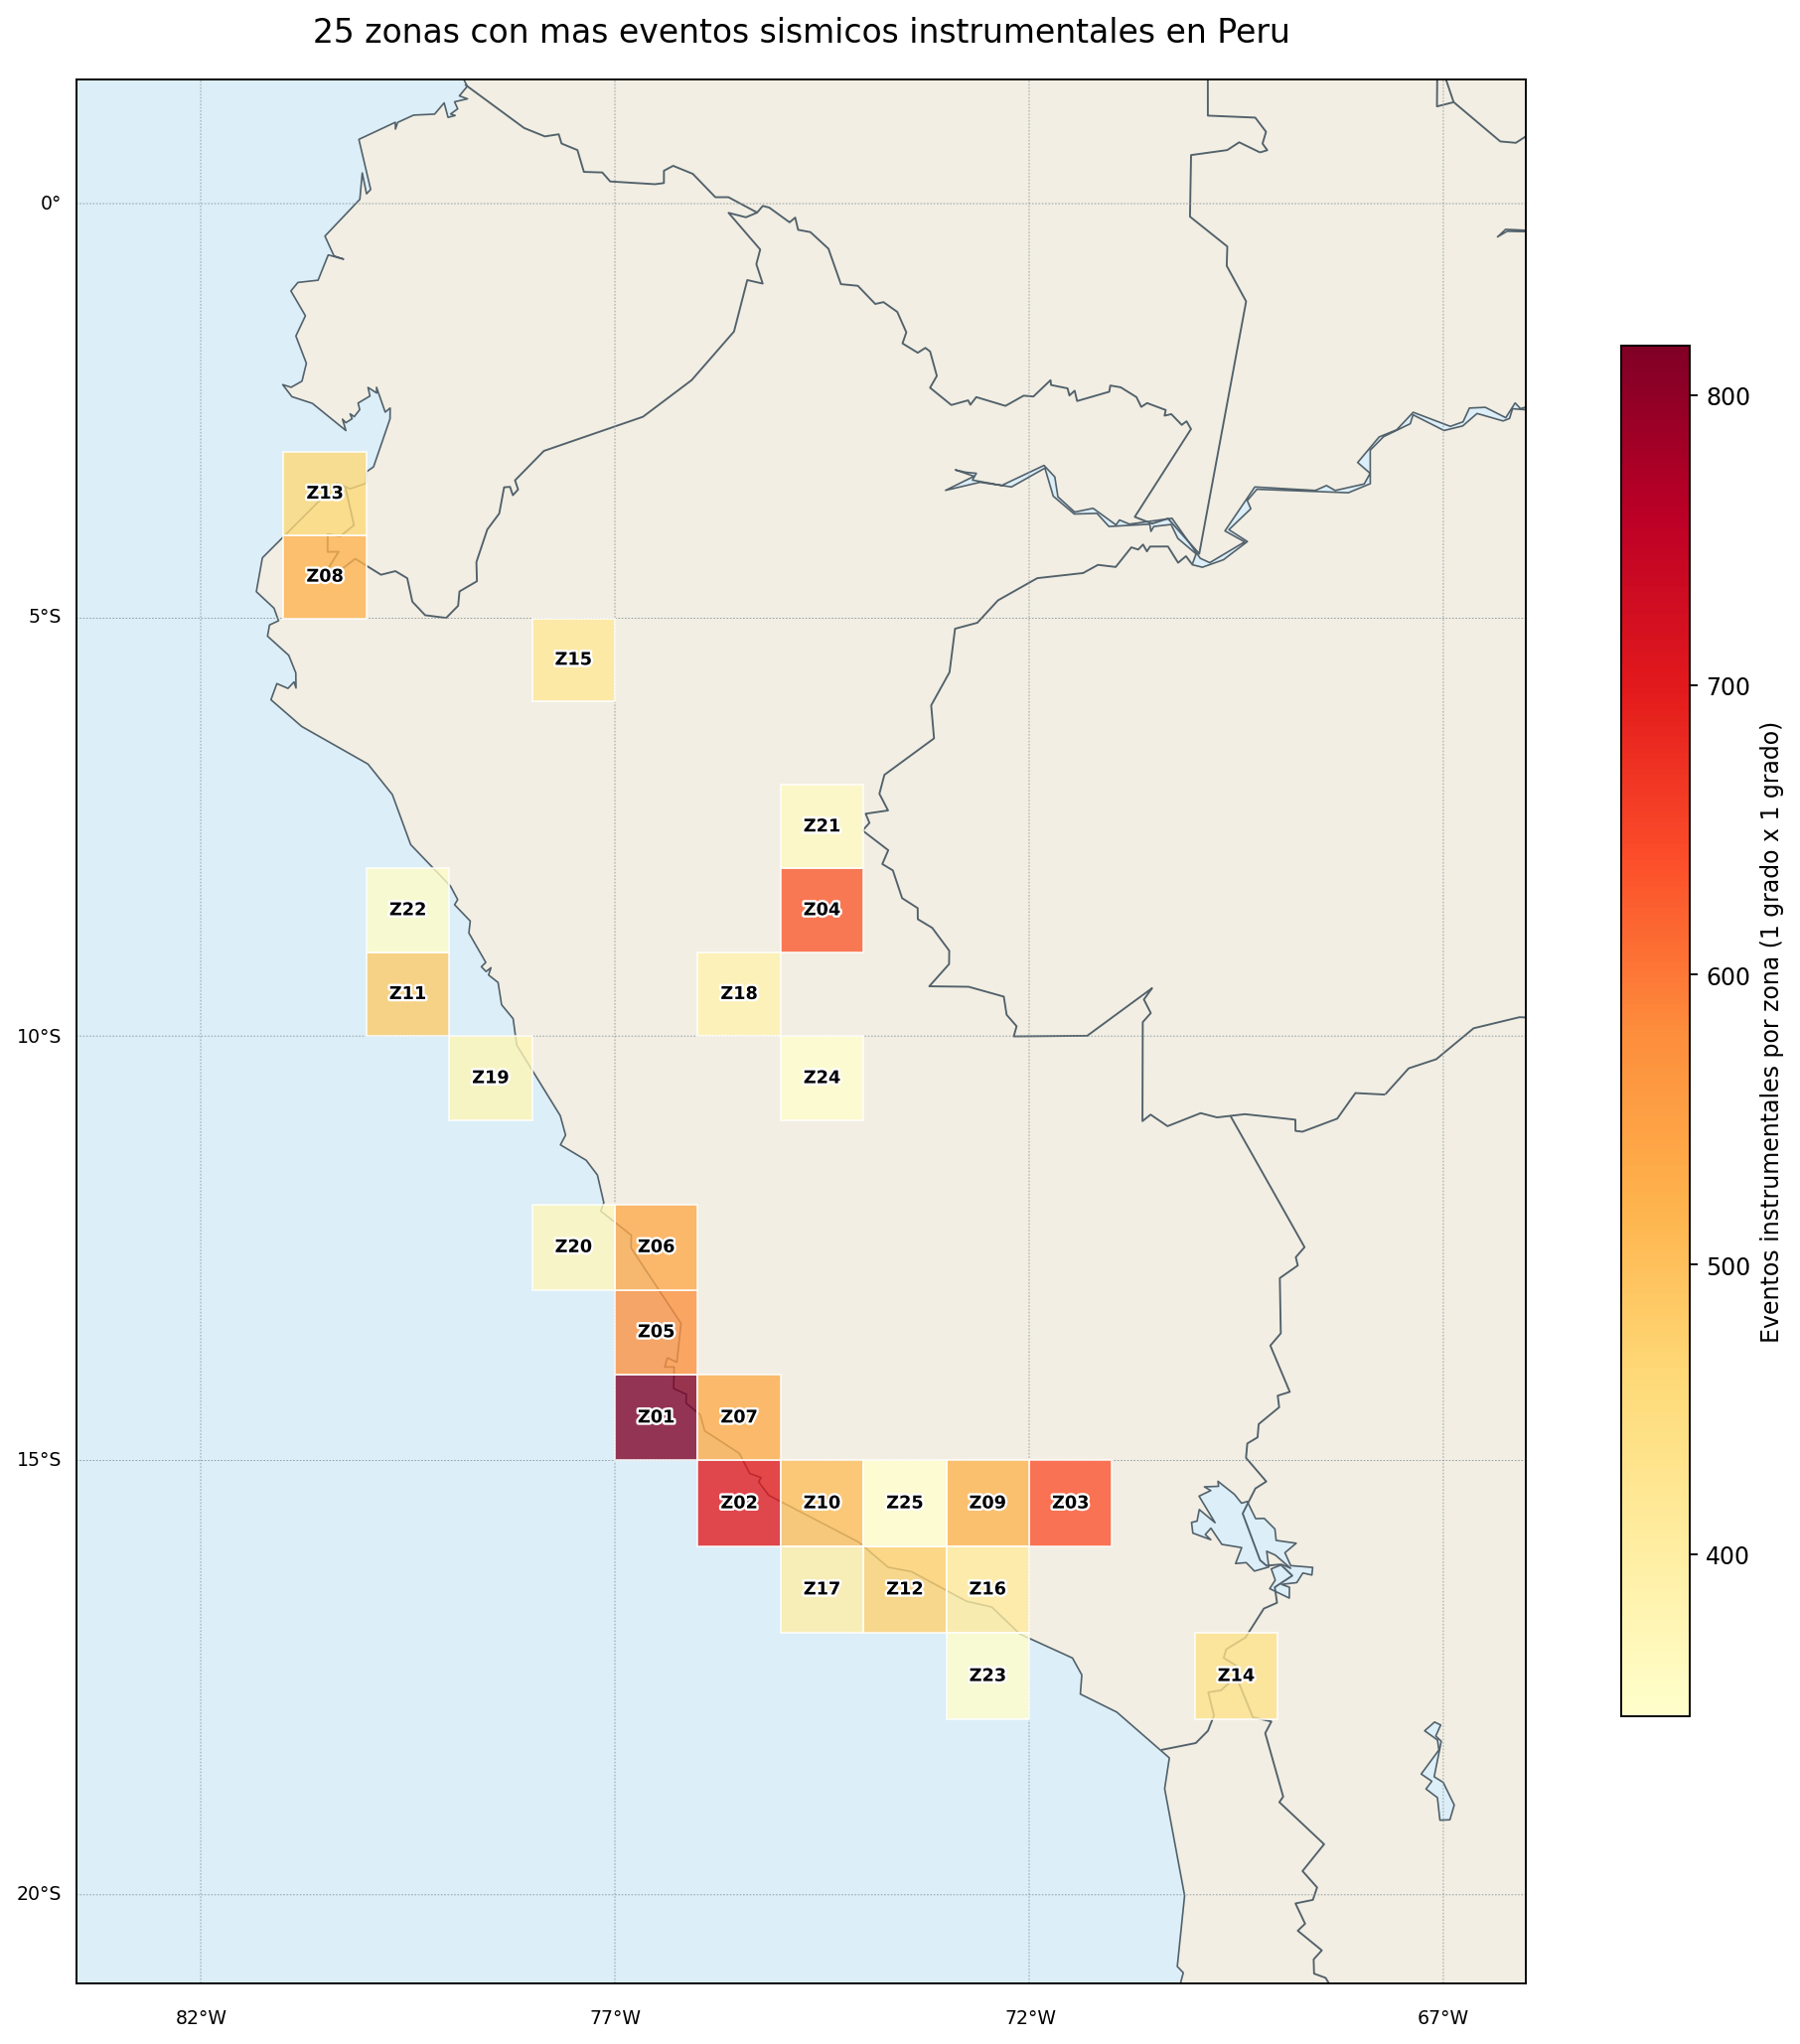

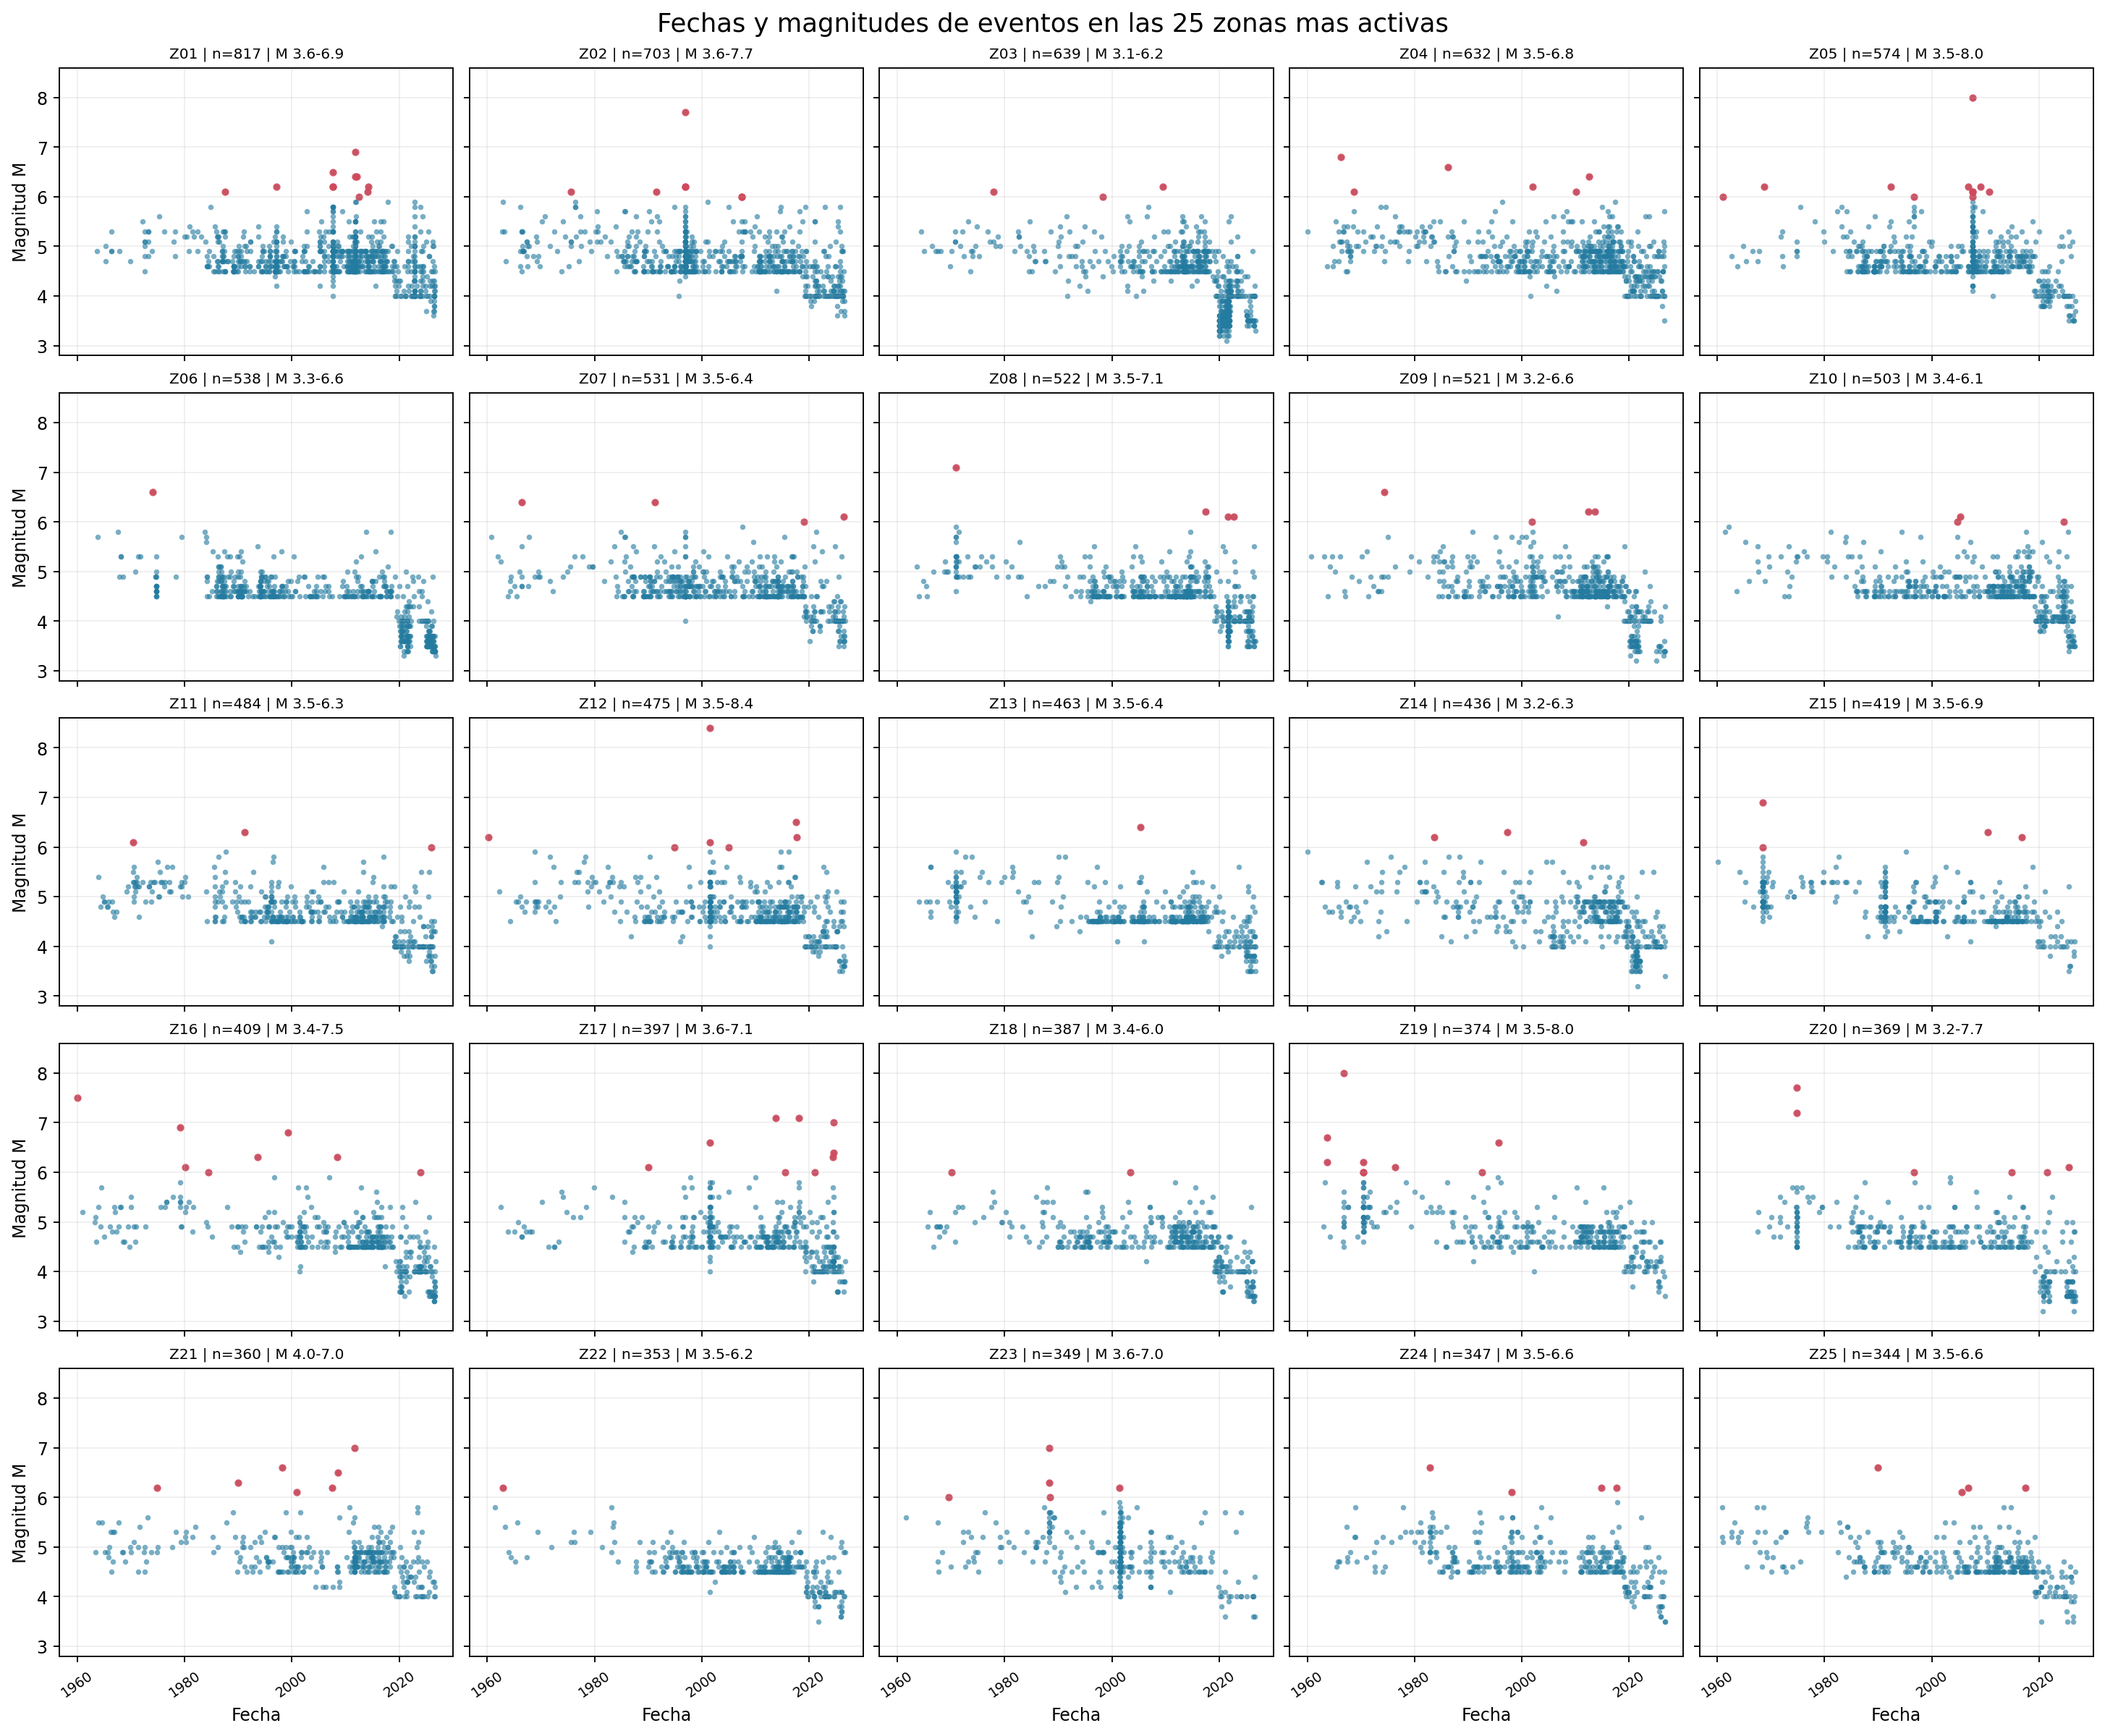

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Polygon
from matplotlib import patheffects
from mpl_toolkits.basemap import Basemap
from IPython.display import display

# Definir zonas como celdas geograficas de 1 grado por 1 grado.
eventos = datos_limpios["instrumental"].dropna(subset=["fecha_utc", "latitud", "longitud", "magnitud_m"]).copy()
eventos["lat_inicio"] = np.floor(eventos["latitud"]).astype(int)
eventos["lon_inicio"] = np.floor(eventos["longitud"]).astype(int)
resumen_zonas = (eventos.groupby(["lat_inicio", "lon_inicio"], as_index=False)
    .agg(eventos=("magnitud_m", "size"), magnitud_min=("magnitud_m", "min"), magnitud_max=("magnitud_m", "max"),
         primera_fecha=("fecha_utc", "min"), ultima_fecha=("fecha_utc", "max")))
top25_zonas = (resumen_zonas.sort_values(["eventos", "lat_inicio", "lon_inicio"], ascending=[False, True, True])
    .head(25).reset_index(drop=True))
top25_zonas["zona"] = [f"Z{i:02d}" for i in range(1, len(top25_zonas)+1)]

# Mapa del Peru y paises vecinos. Basemap dibuja costas y fronteras nacionales.
fig_mapa, ax = plt.subplots(figsize=(11, 12), constrained_layout=True)
m = Basemap(projection="merc", llcrnrlon=-83.5, llcrnrlat=-21.0,
            urcrnrlon=-66.0, urcrnrlat=1.5, resolution="l", ax=ax)
m.drawmapboundary(fill_color="#dceef7", linewidth=0.8)
m.fillcontinents(color="#f2eee3", lake_color="#dceef7", zorder=1)
m.drawcoastlines(color="#52616b", linewidth=0.7, zorder=2)
m.drawcountries(color="#52616b", linewidth=0.8, zorder=2)
m.drawparallels(np.arange(-20, 2, 5), labels=[1,0,0,0], linewidth=0.35, color="#87939b", dashes=[2,2], fontsize=8)
m.drawmeridians(np.arange(-82, -65, 5), labels=[0,0,0,1], linewidth=0.35, color="#87939b", dashes=[2,2], fontsize=8)
conteos = top25_zonas["eventos"].to_numpy()
norm = Normalize(vmin=int(conteos.min()), vmax=int(conteos.max()))
cmap = plt.get_cmap("YlOrRd")
for _, zona in top25_zonas.iterrows():
    x0, y0 = m(zona["lon_inicio"], zona["lat_inicio"])
    x1, y1 = m(zona["lon_inicio"]+1, zona["lat_inicio"]+1)
    patch = Polygon([(x0,y0),(x1,y0),(x1,y1),(x0,y1)], closed=True,
                    facecolor=cmap(norm(zona["eventos"])), edgecolor="white", linewidth=0.8, alpha=0.78, zorder=3)
    ax.add_patch(patch)
    xc, yc = m(zona["lon_inicio"]+0.5, zona["lat_inicio"]+0.5)
    label = ax.text(xc, yc, zona["zona"], ha="center", va="center", fontsize=7.5,
                    color="black", fontweight="bold", zorder=4)
    label.set_path_effects([patheffects.withStroke(linewidth=2, foreground="white")])
sm = ScalarMappable(norm=norm, cmap=cmap)
fig_mapa.colorbar(sm, ax=ax, shrink=0.72, pad=0.06, label="Eventos instrumentales por zona (1 grado x 1 grado)")
ax.set_title("25 zonas con mas eventos sismicos instrumentales en Peru", fontsize=14, pad=16)

# Tabla con conteos, rango de magnitud y periodo observado en cada zona.
tabla_zonas = top25_zonas[["zona", "lat_inicio", "lon_inicio", "eventos", "magnitud_min", "magnitud_max", "primera_fecha", "ultima_fecha"]].copy()
tabla_zonas = tabla_zonas.rename(columns={"zona":"Zona", "lat_inicio":"Lat. inicio", "lon_inicio":"Lon. inicio", "eventos":"Eventos", "magnitud_min":"M min", "magnitud_max":"M max", "primera_fecha":"Primera fecha", "ultima_fecha":"Ultima fecha"})
tabla_zonas["Primera fecha"] = tabla_zonas["Primera fecha"].dt.strftime("%Y-%m-%d")
tabla_zonas["Ultima fecha"] = tabla_zonas["Ultima fecha"].dt.strftime("%Y-%m-%d")
print("TOP 25 ZONAS (latitud/longitud indican el inicio de cada celda de 1 grado)")
print(tabla_zonas.to_string(index=False, formatters={"M min":"{:.1f}".format, "M max":"{:.1f}".format}))
display(tabla_zonas)

# Small multiples: fecha vs magnitud para cada zona, con ejes compartidos.
eventos_top = eventos.merge(top25_zonas[["lat_inicio", "lon_inicio", "zona"]], on=["lat_inicio", "lon_inicio"], how="inner")
fig_tiempo, axes = plt.subplots(5, 5, figsize=(17, 14), sharex=True, sharey=True, constrained_layout=True)
for ax, (_, zona) in zip(axes.flat, top25_zonas.iterrows()):
    d = eventos_top.loc[eventos_top["zona"] == zona["zona"]]
    ax.scatter(d["fecha_utc"], d["magnitud_m"], s=10, alpha=0.62, color="#247ba0", linewidths=0, rasterized=True)
    d_altos = d.loc[d["magnitud_m"] >= 6]
    if not d_altos.empty:
        ax.scatter(d_altos["fecha_utc"], d_altos["magnitud_m"], s=19, color="#d1495b", alpha=0.9, linewidths=0, rasterized=True)
    ax.set_title(f"{zona['zona']} | n={int(zona['eventos'])} | M {zona['magnitud_min']:.1f}-{zona['magnitud_max']:.1f}", fontsize=8.5)
    ax.grid(alpha=0.2)
    ax.set_ylim(2.8, 8.6)
    ax.xaxis.set_major_locator(mdates.YearLocator(20))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
for ax in axes[-1,:]:
    ax.tick_params(axis="x", labelrotation=35, labelsize=8)
for ax in axes[:,0]:
    ax.set_ylabel("Magnitud M")
for ax in axes[-1,:]:
    ax.set_xlabel("Fecha")
fig_tiempo.suptitle("Fechas y magnitudes de eventos en las 25 zonas mas activas", fontsize=15)

fig_dir = Path(r"C:\Users\user\curso-ia-web\Grupo2_UPC_ML\figuras")
fig_dir.mkdir(exist_ok=True)
fig_mapa.savefig(fig_dir / "T2_top25_zonas_mapa_peru.png", dpi=170, bbox_inches="tight")
fig_tiempo.savefig(fig_dir / "T2_top25_zonas_fechas_magnitudes.png", dpi=170, bbox_inches="tight")
print(f"\nEventos incluidos: {len(eventos_top):,} de {len(eventos):,}; zonas definidas en celdas de 1 grado.")
print(f"Zona principal {top25_zonas.iloc[0]['zona']}: {int(top25_zonas.iloc[0]['eventos']):,} eventos, M {top25_zonas.iloc[0]['magnitud_min']:.1f}-{top25_zonas.iloc[0]['magnitud_max']:.1f}.")
print("La serie temporal compara magnitudes observadas; no interpola valores en fechas sin eventos.")
display(fig_mapa)
display(fig_tiempo)
plt.close(fig_mapa)
plt.close(fig_tiempo)


## Pronóstico experimental con BiLSTM: evaluación temporal y horizonte de 24 semanas
Se filtran eventos instrumentales con magnitud **M > 4**. Para cada ciudad de referencia, el objetivo semanal es que ocurra al menos un evento dentro de **100 km**. La red bidireccional recibe únicamente las 52 semanas previas. Se ajusta hasta diciembre de 2018; se valida 2019–2021 y se corrobora 2022–2023 con el mismo modelo congelado y ventanas móviles de observaciones ya ocurridas. Al final se reentrena con todo el instrumental hasta su última fecha. Las coordenadas urbanas son aproximadas, y la proyección de 24 semanas es recursiva.

> Es una estimación exploratoria, no una alerta ni una predicción determinista. El catálogo instrumental refleja cambios de cobertura y detección a lo largo del tiempo.


Eventos M>4 en catálogo: 23,091; última fecha total: 2026-10-01.
Entrenamiento: 1960–2018; validación: 2019–2021; corroboración: 2022–2023; lookback: 52 semanas.
Evento objetivo: al menos un M>4 a 100 km del punto de referencia urbano en la semana.


,semanas-ciudad,tasa observada,prob. media BiLSTM,Brier BiLSTM,Brier referencia (tasa train),AUC
periodo,,,,,,
Validación 2019–2021,3900,0.1200,0.1188,0.0995,0.1058,0.7139
Corroboración 2022–2023,2625,0.1013,0.0997,0.0869,0.0911,0.7107


<Figure size 1400x500 with 1 Axes>

Pronóstico recursivo: 05-10-2026 a 15-03-2027.
Probabilidad significa al menos un M>4 dentro de 100 km en esa semana; las 24 semanas recursivas no son independientes.


,ciudad,lat_ciudad,lon_ciudad,probabilidad_media_24s,probabilidad_semana_1,probabilidad_max_24s
0,Pucallpa,-8.3791,-74.5539,0.2912,0.2721,0.3156
1,Ica,-14.0678,-75.7286,0.2742,0.2417,0.3115
2,Tacna,-18.0066,-70.2463,0.2254,0.2094,0.2399
3,Tumbes,-3.5669,-80.4515,0.2198,0.1907,0.2611
4,Lima,-12.0464,-77.0428,0.2069,0.1851,0.2226
5,Piura,-5.1945,-80.6328,0.1705,0.1461,0.1949
6,Huancayo,-12.0651,-75.2049,0.1690,0.1401,0.1997
7,Chimbote,-9.0853,-78.5783,0.1489,0.1413,0.1678
8,Tarapoto,-6.4870,-76.3650,0.1062,0.0864,0.1247
9,Moquegua,-17.1939,-70.9328,0.1035,0.1029,0.1197


<Figure size 1400x700 with 2 Axes>

<Figure size 1700x1200 with 3 Axes>

Nota: salida experimental, no es una predicción determinista ni un sistema de alerta. Las coordenadas urbanas son aproximadas; se cuentan eventos instrumentales observados en 100 km.


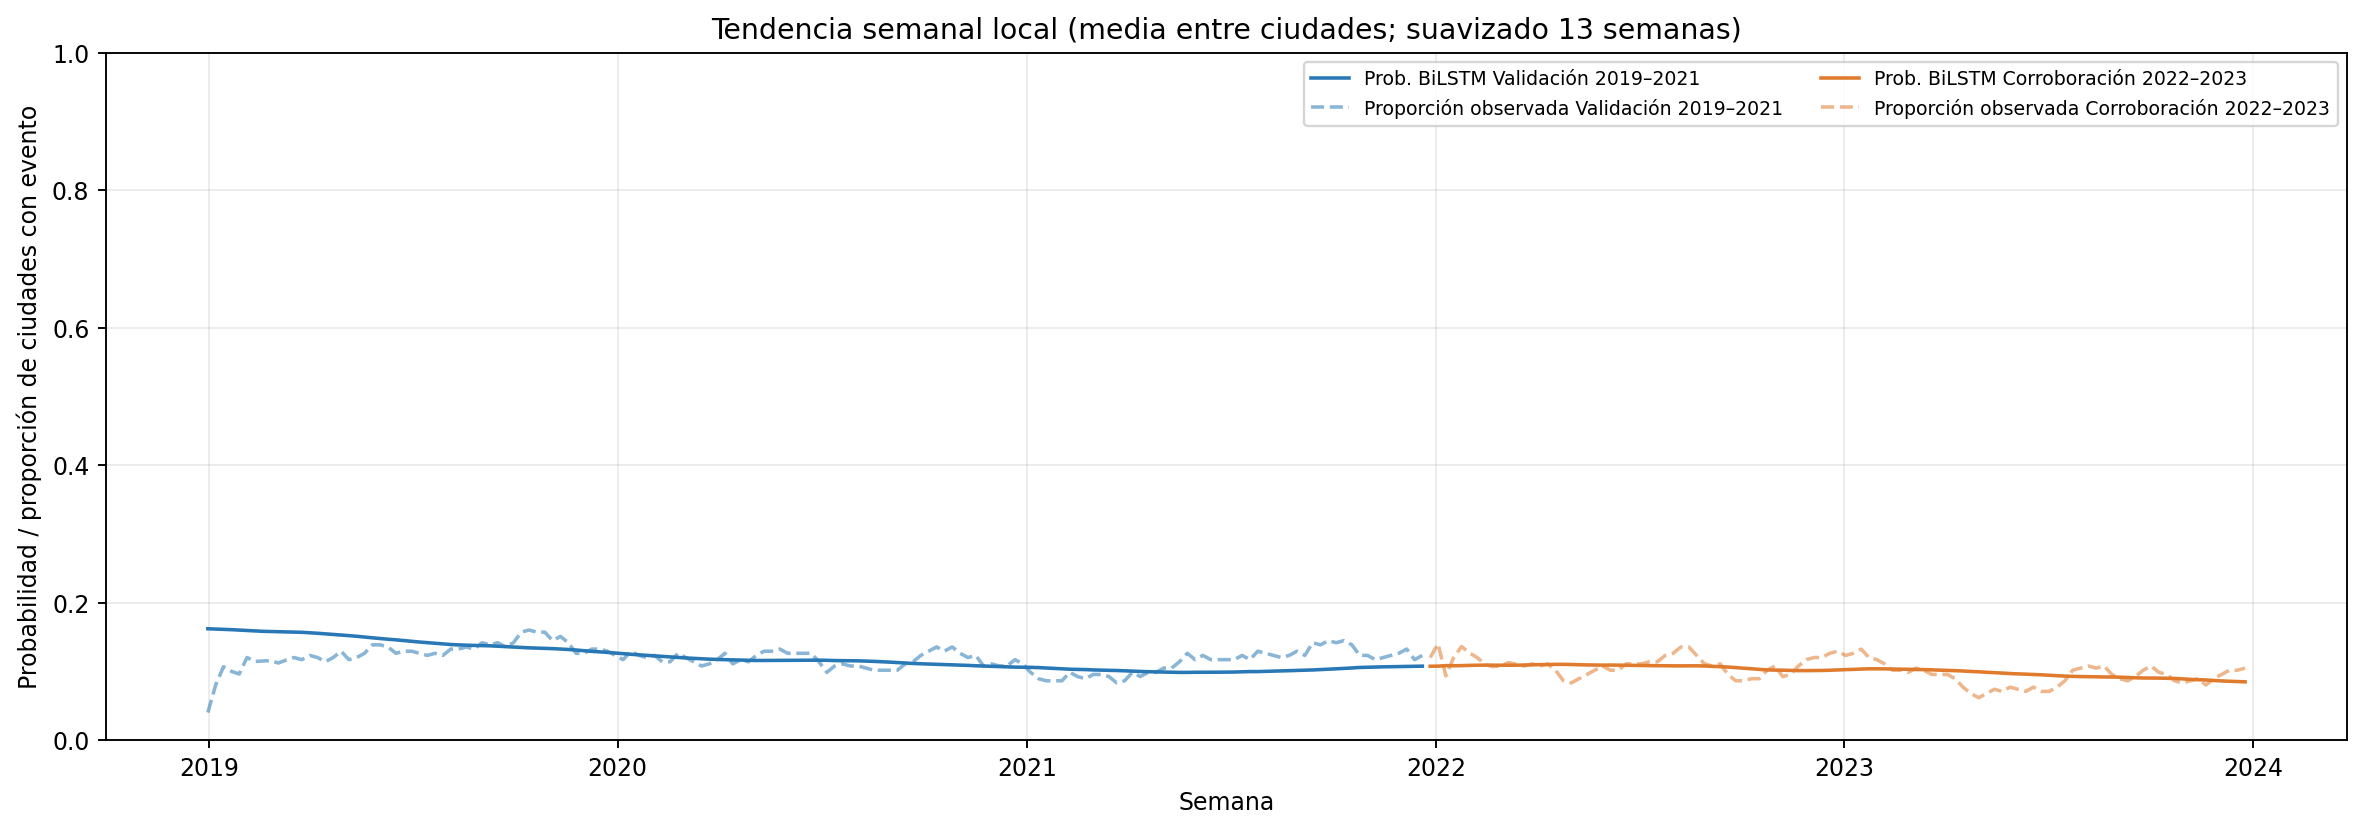

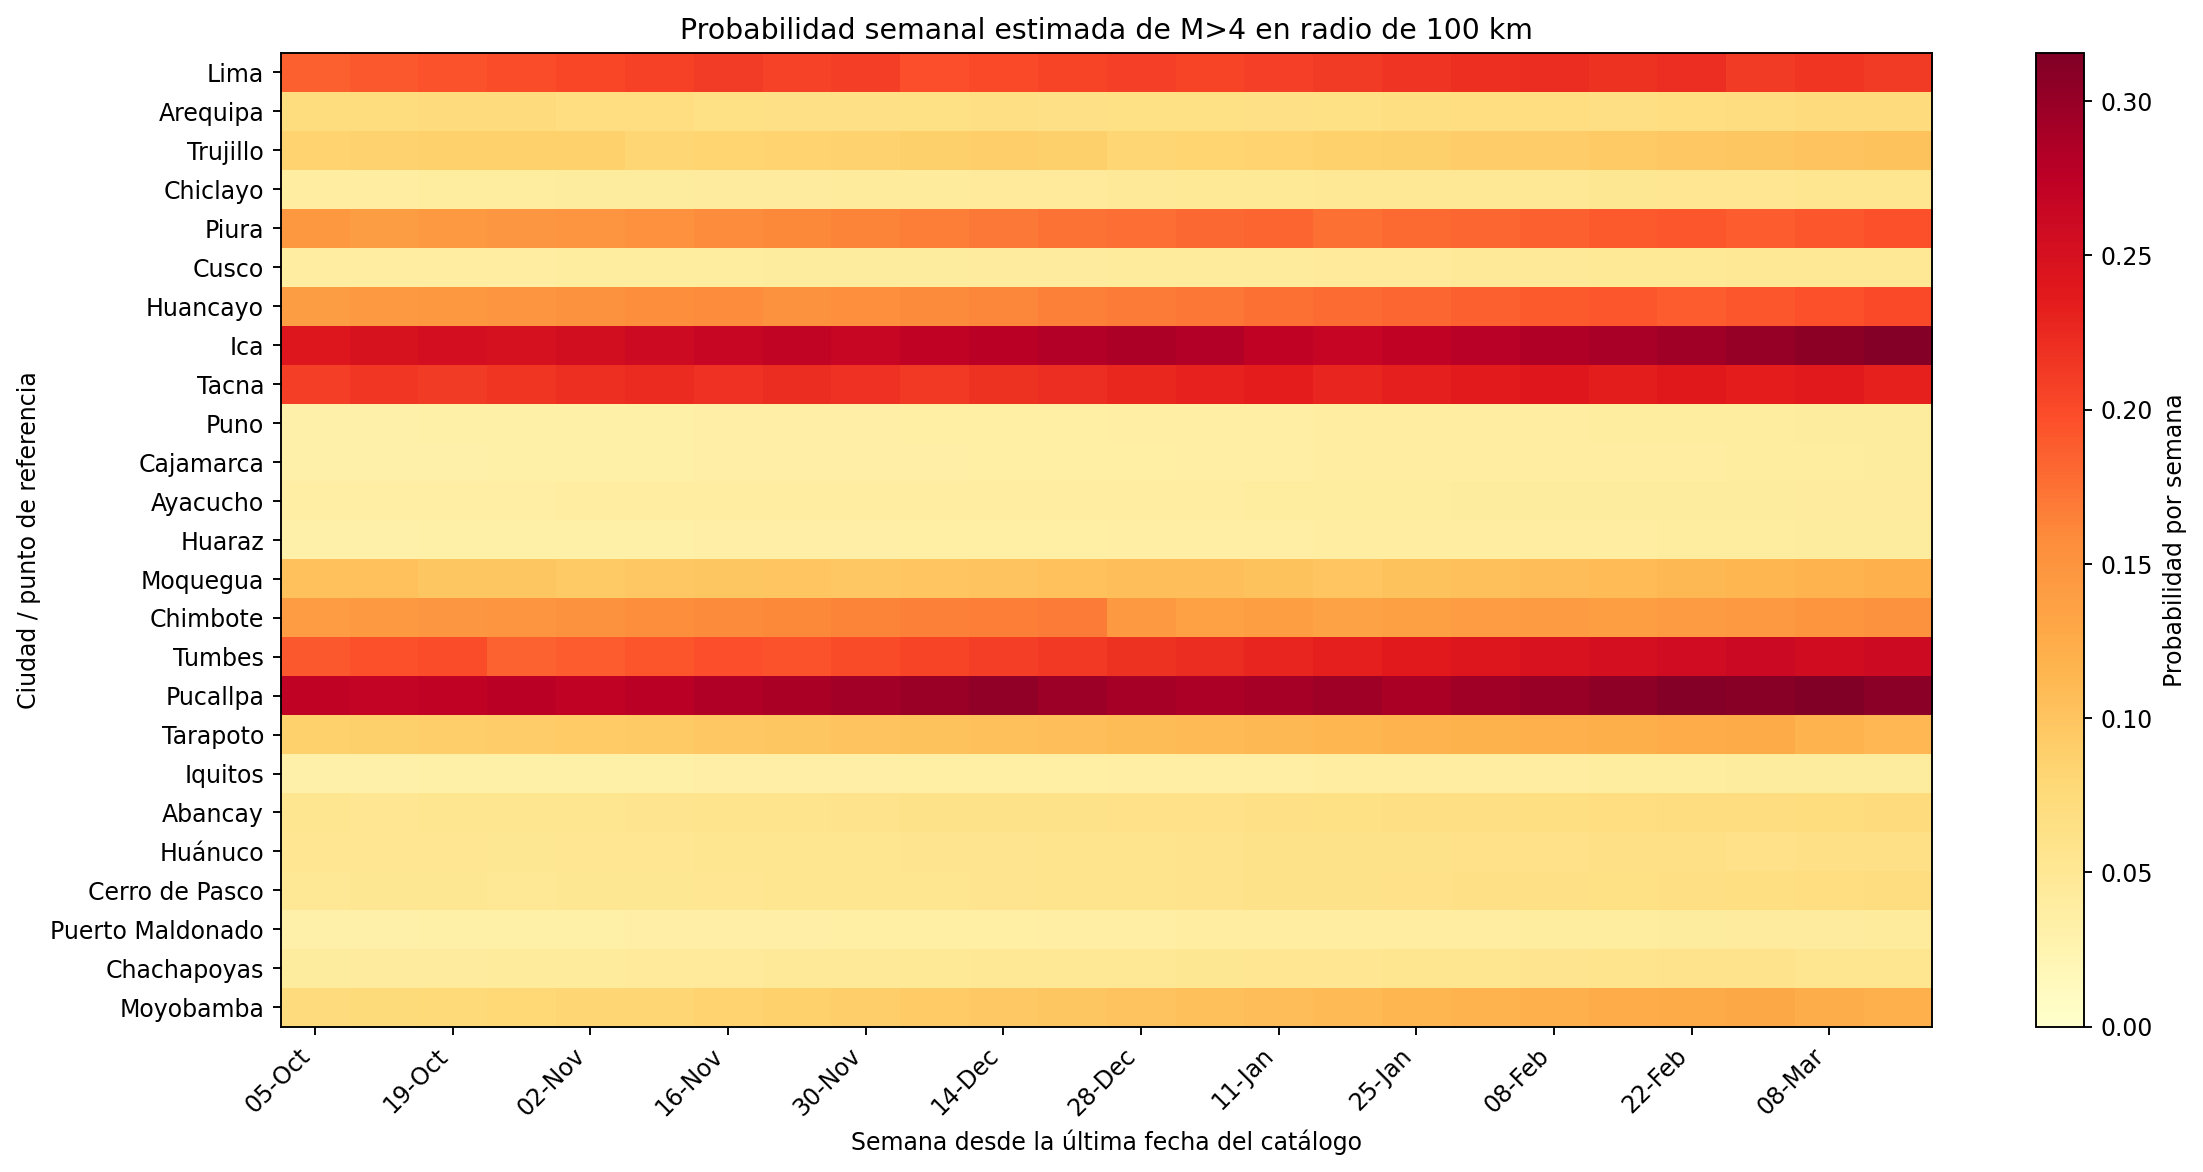

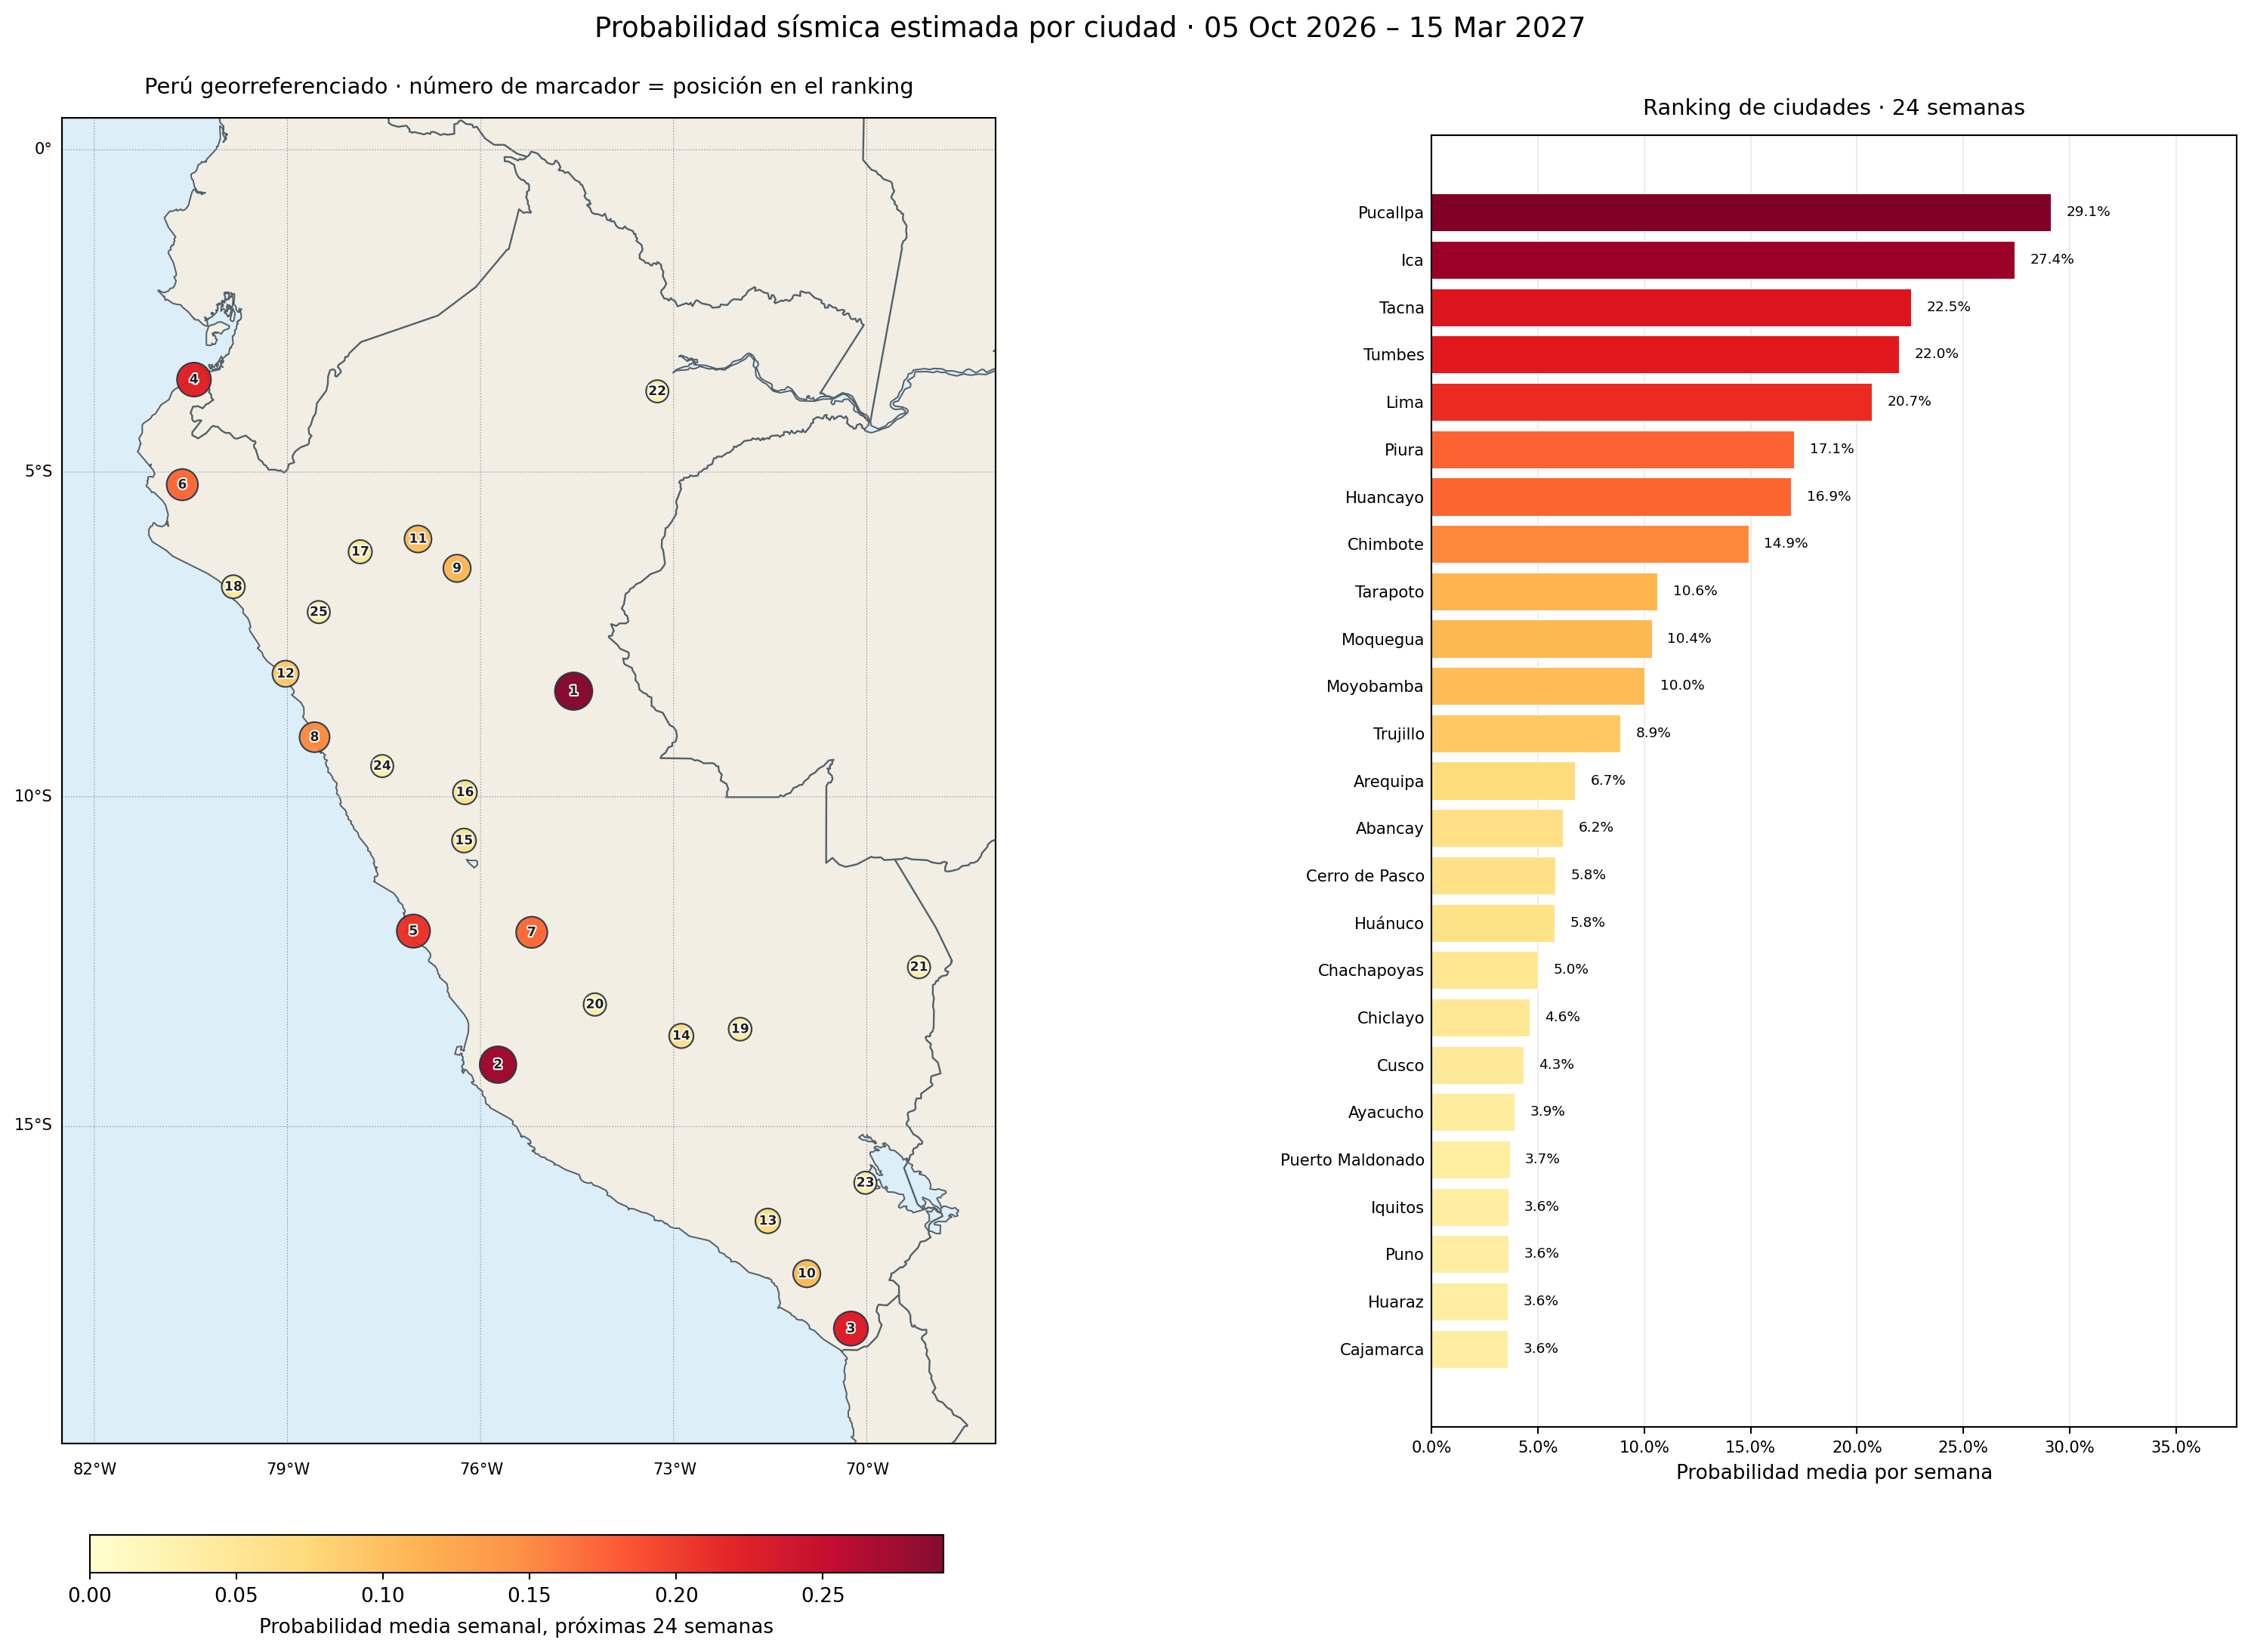

In [6]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import display
from pathlib import Path

figuras_dir = Path(r"C:\Users\user\curso-ia-web\Grupo2_UPC_ML\figuras")
figuras_dir.mkdir(parents=True, exist_ok=True)
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.utils.class_weight import compute_class_weight

# Pronóstico experimental por ciudad: evento = al menos un M>4 a <=100 km.
# Coordenadas urbanas aproximadas usadas solo como puntos de consulta espacial.
ciudades_peru = pd.DataFrame([
    ("Lima", -12.0464, -77.0428), ("Arequipa", -16.4090, -71.5375),
    ("Trujillo", -8.1116, -79.0288), ("Chiclayo", -6.7714, -79.8409),
    ("Piura", -5.1945, -80.6328), ("Cusco", -13.5319, -71.9675),
    ("Huancayo", -12.0651, -75.2049), ("Ica", -14.0678, -75.7286),
    ("Tacna", -18.0066, -70.2463), ("Puno", -15.8402, -70.0219),
    ("Cajamarca", -7.1617, -78.5128), ("Ayacucho", -13.1588, -74.2239),
    ("Huaraz", -9.5278, -77.5278), ("Moquegua", -17.1939, -70.9328),
    ("Chimbote", -9.0853, -78.5783), ("Tumbes", -3.5669, -80.4515),
    ("Pucallpa", -8.3791, -74.5539), ("Tarapoto", -6.4870, -76.3650),
    ("Iquitos", -3.7491, -73.2538), ("Abancay", -13.6339, -72.8814),
    ("Huánuco", -9.9306, -76.2422), ("Cerro de Pasco", -10.6675, -76.2567),
    ("Puerto Maldonado", -12.5933, -69.1891), ("Chachapoyas", -6.2317, -77.8690),
    ("Moyobamba", -6.0342, -76.9717),
], columns=["ciudad", "lat_ciudad", "lon_ciudad"])

tf.keras.utils.set_random_seed(42)
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)

instrumental_modelo = datos_limpios["instrumental"].copy()
eventos_m4 = instrumental_modelo.dropna(
    subset=["fecha_utc", "latitud", "longitud", "magnitud_m"]
).copy()
eventos_m4 = eventos_m4[eventos_m4["magnitud_m"] > 4].copy()
ultima_fecha_catalogo = pd.to_datetime(instrumental_modelo["fecha_utc"]).max().normalize()
eventos_m4["fecha_utc"] = pd.to_datetime(eventos_m4["fecha_utc"])
inicio_semana = pd.Timestamp("1960-01-04")
fin_semana = ultima_fecha_catalogo.normalize() - pd.Timedelta(days=ultima_fecha_catalogo.weekday())
semanas = pd.date_range(inicio_semana, fin_semana, freq="W-MON")
n_sem = len(semanas)

# Matrices semanales por ciudad; las semanas sin eventos se conservan como cero.
conteos = np.zeros((len(ciudades_peru), n_sem), dtype=np.float32)
magnitud_max = np.zeros_like(conteos)
rad = np.pi / 180.0
for j, ciudad in ciudades_peru.iterrows():
    lat1 = eventos_m4["latitud"].to_numpy(dtype=float) * rad
    lon1 = eventos_m4["longitud"].to_numpy(dtype=float) * rad
    lat2, lon2 = ciudad["lat_ciudad"] * rad, ciudad["lon_ciudad"] * rad
    a = np.sin((lat1-lat2)/2)**2 + np.cos(lat2)*np.cos(lat1)*np.sin((lon1-lon2)/2)**2
    dist_km = 6371.0088 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
    local = eventos_m4.loc[dist_km <= 100, ["fecha_utc", "magnitud_m"]].copy()
    if not local.empty:
        local["semana"] = local["fecha_utc"].dt.normalize() - pd.to_timedelta(local["fecha_utc"].dt.weekday, unit="D")
        agg = local.groupby("semana")["magnitud_m"].agg(["size", "max"])
        idx = semanas.get_indexer(agg.index)
        valid = idx >= 0
        conteos[j, idx[valid]] = agg["size"].to_numpy(dtype=np.float32)[valid]
        magnitud_max[j, idx[valid]] = agg["max"].to_numpy(dtype=np.float32)[valid]

# Dos predictores disponibles al cierre de cada semana; BiLSTM ve solo las 52 semanas previas.
caracteristicas = np.stack([
    np.log1p(conteos) / np.log(10.0),
    np.maximum(magnitud_max - 4.0, 0.0) / 4.0,
], axis=-1)
objetivo = (conteos > 0).astype(np.float32)
LOOKBACK = 52
fechas_objetivo = semanas[LOOKBACK:]
X_todo, y_todo, meta = [], [], []
for j in range(len(ciudades_peru)):
    for t in range(LOOKBACK, n_sem):
        X_todo.append(caracteristicas[j, t-LOOKBACK:t, :])
        y_todo.append(objetivo[j, t])
        meta.append((j, t))
X_todo = np.asarray(X_todo, dtype=np.float32)
y_todo = np.asarray(y_todo, dtype=np.float32)
meta = np.asarray(meta, dtype=np.int32)
fecha_target = semanas[meta[:, 1]]
cut_2018 = pd.Timestamp("2018-12-31")
cut_2021 = pd.Timestamp("2021-12-31")
cut_2023 = pd.Timestamp("2023-12-31")
cierre_target = fecha_target + pd.Timedelta(days=6)
mask_train = cierre_target <= cut_2018
mask_val = (cierre_target > cut_2018) & (cierre_target <= cut_2021)
mask_test = (cierre_target > cut_2021) & (cierre_target <= cut_2023)

def crear_bilstm():
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(LOOKBACK, 2)),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16, dropout=0.15)),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss="binary_crossentropy", metrics=[tf.keras.metrics.AUC(name="auc")])
    return modelo

def metricas_periodo(nombre, mascara, modelo):
    y = y_todo[mascara].astype(int)
    p = np.clip(modelo.predict(X_todo[mascara], verbose=0).ravel(), 1e-6, 1-1e-6)
    base = float(y_todo[mask_train].mean())
    return {"periodo": nombre, "semanas-ciudad": len(y),
            "tasa observada": float(y.mean()), "prob. media BiLSTM": float(p.mean()),
            "Brier BiLSTM": float(brier_score_loss(y, p)),
            "Brier referencia (tasa train)": float(brier_score_loss(y, np.full(len(y), base))),
            "AUC": float(roc_auc_score(y, p)) if len(np.unique(y)) > 1 else np.nan}, p

modelo_2018 = crear_bilstm()
modelo_2018.fit(X_todo[mask_train], y_todo[mask_train], epochs=5, batch_size=2048,
                shuffle=True, verbose=0)
res_val, p_val = metricas_periodo("Validación 2019–2021", mask_val, modelo_2018)
res_test, p_test = metricas_periodo("Corroboración 2022–2023", mask_test, modelo_2018)
tabla_validacion = pd.DataFrame([res_val, res_test]).set_index("periodo")
print(f"Eventos M>4 en catálogo: {len(eventos_m4):,}; última fecha total: {ultima_fecha_catalogo:%Y-%m-%d}.")
print(f"Entrenamiento: 1960–2018; validación: 2019–2021; corroboración: 2022–2023; lookback: {LOOKBACK} semanas.")
print("Evento objetivo: al menos un M>4 a 100 km del punto de referencia urbano en la semana.")
display(tabla_validacion.round(4))

# Tendencia evaluada de forma walk-forward: en cada semana se usan observaciones ya ocurridas,
# y el modelo permanece congelado con pesos aprendidos hasta diciembre de 2018.
def vector_indice(mask):
    inds = np.flatnonzero(mask)
    return inds

def resumen_semanal(mask, probs):
    indices = vector_indice(mask)
    submeta = meta[indices]
    por_semana = {}
    for k, idx in enumerate(indices):
        t = meta[idx, 1]
        por_semana.setdefault(t, []).append(probs[k])
    ts = np.array(sorted(por_semana), dtype=int)
    pmean = np.array([np.mean(por_semana[t]) for t in ts])
    observado = np.array([objetivo[:, t].mean() for t in ts])
    return semanas[ts], pmean, observado

fig, ax = plt.subplots(figsize=(14, 5))
for m, p, label, color in [(mask_val, p_val, "Validación 2019–2021", "#2878B5"),
                            (mask_test, p_test, "Corroboración 2022–2023", "#E07A2D")]:
    f, pred, obs = resumen_semanal(m, p)
    s_pred = pd.Series(pred, index=f).rolling(13, min_periods=1).mean()
    s_obs = pd.Series(obs, index=f).rolling(13, min_periods=1).mean()
    ax.plot(s_pred.index, s_pred, color=color, label=f"Prob. BiLSTM {label}")
    ax.plot(s_obs.index, s_obs, color=color, alpha=.55, linestyle="--", label=f"Proporción observada {label}")
ax.set(title="Tendencia semanal local (media entre ciudades; suavizado 13 semanas)",
       ylabel="Probabilidad / proporción de ciudades con evento", xlabel="Semana")
ax.set_ylim(0, 1); ax.grid(alpha=.25); ax.legend(ncol=2, fontsize=8); fig.tight_layout()
fig.savefig(figuras_dir / "T2_bilstm_evaluacion_temporal.png", dpi=170, bbox_inches="tight")
display(fig); plt.close(fig)

# Reentrenamiento con todo el catálogo disponible hasta la última fecha y proyección recursiva.
modelo_final = crear_bilstm()
modelo_final.fit(X_todo[cierre_target <= ultima_fecha_catalogo], y_todo[cierre_target <= ultima_fecha_catalogo],
                 epochs=5, batch_size=2048, shuffle=True, verbose=0)
fechas_futuras = pd.date_range(fin_semana + pd.Timedelta(days=7), periods=24, freq="W-MON")
pronostico = np.zeros((len(ciudades_peru), 24), dtype=float)
for j in range(len(ciudades_peru)):
    hist = caracteristicas[j, -LOOKBACK:, :].copy()
    local_counts = conteos[j, conteos[j] > 0]
    local_mags = magnitud_max[j, magnitud_max[j] > 4]
    count_cond = float(local_counts.mean()) if len(local_counts) else float(conteos[conteos > 0].mean())
    mag_cond = float(local_mags.mean()) if len(local_mags) else float(eventos_m4["magnitud_m"].mean())
    for h in range(24):
        prob = float(modelo_final.predict(hist[None, :, :], verbose=0)[0, 0])
        pronostico[j, h] = prob
        esperado_count = prob * count_cond
        esperado_mag = prob * max(mag_cond - 4.0, 0.0) / 4.0
        hist = np.vstack([hist[1:], [np.log1p(esperado_count)/np.log(10.0), esperado_mag]])

tabla_pronostico = ciudades_peru[["ciudad", "lat_ciudad", "lon_ciudad"]].copy()
tabla_pronostico["probabilidad_media_24s"] = pronostico.mean(axis=1)
tabla_pronostico["probabilidad_semana_1"] = pronostico[:, 0]
tabla_pronostico["probabilidad_max_24s"] = pronostico.max(axis=1)
tabla_pronostico = tabla_pronostico.sort_values("probabilidad_media_24s", ascending=False).reset_index(drop=True)
print(f"Pronóstico recursivo: {fechas_futuras[0]:%d-%m-%Y} a {fechas_futuras[-1]:%d-%m-%Y}.")
print("Probabilidad significa al menos un M>4 dentro de 100 km en esa semana; las 24 semanas recursivas no son independientes.")
display(tabla_pronostico.round(4))

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(pronostico, aspect="auto", cmap="YlOrRd", vmin=0, vmax=max(.05, float(pronostico.max())))
ax.set_yticks(range(len(ciudades_peru))); ax.set_yticklabels(ciudades_peru["ciudad"])
paso = 2
ax.set_xticks(np.arange(0, 24, paso)); ax.set_xticklabels([f"{fechas_futuras[i]:%d-%b}" for i in range(0,24,paso)], rotation=45, ha="right")
ax.set(title="Probabilidad semanal estimada de M>4 en radio de 100 km", xlabel="Semana desde la última fecha del catálogo", ylabel="Ciudad / punto de referencia")
fig.colorbar(im, ax=ax, label="Probabilidad por semana"); fig.tight_layout()
fig.savefig(figuras_dir / "T2_bilstm_pronostico_semanal.png", dpi=170, bbox_inches="tight")
display(fig); plt.close(fig)

from mpl_toolkits.basemap import Basemap
from matplotlib.colors import Normalize
import matplotlib.patheffects as patheffects
from matplotlib.ticker import PercentFormatter

# Clasificacion coherente entre el mapa numerado y el ranking lateral.
ranking_mapa = tabla_pronostico.sort_values("probabilidad_media_24s", ascending=False).reset_index(drop=True).copy()
ranking_mapa["rango"] = np.arange(1, len(ranking_mapa) + 1)
prob_por_ciudad = tabla_pronostico.set_index("ciudad")["probabilidad_media_24s"]
prob_ciudades = ciudades_peru["ciudad"].map(prob_por_ciudad).to_numpy(dtype=float)
vmax = max(1e-6, float(prob_ciudades.max()))
norm = Normalize(vmin=0, vmax=vmax)
cmap = plt.get_cmap("YlOrRd")
rangos = ranking_mapa.set_index("ciudad")["rango"]

# Proyeccion Mercator y limites que incluyen el territorio peruano y sus fronteras.
from mpl_toolkits.basemap import Basemap
from matplotlib.colors import Normalize
import matplotlib.patheffects as patheffects
from matplotlib.ticker import PercentFormatter

# Clasificacion coherente entre el mapa numerado y el ranking lateral.
ranking_mapa = tabla_pronostico.sort_values("probabilidad_media_24s", ascending=False).reset_index(drop=True).copy()
ranking_mapa["rango"] = np.arange(1, len(ranking_mapa) + 1)
prob_por_ciudad = tabla_pronostico.set_index("ciudad")["probabilidad_media_24s"]
prob_ciudades = ciudades_peru["ciudad"].map(prob_por_ciudad).to_numpy(dtype=float)
vmax = max(1e-6, float(prob_ciudades.max()))
norm = Normalize(vmin=0, vmax=vmax)
cmap = plt.get_cmap("YlOrRd")
rangos = ranking_mapa.set_index("ciudad")["rango"]

# Proyeccion Mercator y limites que incluyen el territorio peruano y sus fronteras.
fig = plt.figure(figsize=(17, 12))
ax_mapa = fig.add_axes([0.035, 0.15, 0.47, 0.77])
ax_ranking = fig.add_axes([0.64, 0.16, 0.33, 0.75])
m = Basemap(projection="merc", llcrnrlon=-82.5, llcrnrlat=-19.7,
            urcrnrlon=-68.0, urcrnrlat=0.5, resolution="i", ax=ax_mapa)
m.drawmapboundary(fill_color="#dceef7", linewidth=0.8)
m.fillcontinents(color="#f2eee3", lake_color="#dceef7", zorder=1)
m.drawcoastlines(color="#52616b", linewidth=0.75, zorder=2)
m.drawcountries(color="#52616b", linewidth=0.9, zorder=2)
m.drawparallels(np.arange(-20, 1, 5), labels=[1, 0, 0, 0], linewidth=0.35,
                color="#87939b", dashes=[2, 2], fontsize=8)
m.drawmeridians(np.arange(-82, -67, 3), labels=[0, 0, 0, 1], linewidth=0.35,
                color="#87939b", dashes=[2, 2], fontsize=8)

x_ciudades, y_ciudades = m(ciudades_peru["lon_ciudad"].to_numpy(), ciudades_peru["lat_ciudad"].to_numpy())
sc = m.scatter(x_ciudades, y_ciudades, c=prob_ciudades, cmap=cmap, norm=norm,
               s=95 + 260 * prob_ciudades / vmax, edgecolors="#283747",
               linewidths=0.8, alpha=0.95, zorder=4)
for i, ciudad in ciudades_peru["ciudad"].items():
    rango = int(rangos.loc[ciudad])
    ax_mapa.annotate(str(rango), (x_ciudades[i], y_ciudades[i]), xytext=(0, 0),
                     textcoords="offset points", ha="center", va="center",
                     fontsize=6.5, fontweight="bold", color="#202020", zorder=5,
                     path_effects=[patheffects.withStroke(linewidth=1.5, foreground="white")])
ax_mapa.set_title("Perú georreferenciado · número de marcador = posición en el ranking", fontsize=11, pad=12)

# Ranking horizontal para leer los nombres y comparar probabilidades sin saturar el mapa.
ranking_plot = ranking_mapa.iloc[::-1]
bar_colors = [cmap(norm(p)) for p in ranking_plot["probabilidad_media_24s"]]
bars = ax_ranking.barh(ranking_plot["ciudad"], ranking_plot["probabilidad_media_24s"],
                       color=bar_colors, edgecolor="white", linewidth=0.4)
ax_ranking.set_xlim(0, vmax * 1.30)
ax_ranking.xaxis.set_major_formatter(PercentFormatter(1.0))
ax_ranking.set_xlabel("Probabilidad media por semana")
ax_ranking.set_title("Ranking de ciudades · 24 semanas", fontsize=11, pad=10)
ax_ranking.tick_params(axis="y", labelsize=8, length=0)
ax_ranking.tick_params(axis="x", labelsize=8)
ax_ranking.grid(axis="x", alpha=0.22)
ax_ranking.set_axisbelow(True)
for bar, valor in zip(bars, ranking_plot["probabilidad_media_24s"]):
    ax_ranking.text(bar.get_width() + vmax * 0.025, bar.get_y() + bar.get_height() / 2,
                    f"{valor:.1%}", va="center", fontsize=7)

cax = fig.add_axes([0.09, 0.075, 0.35, 0.022])
cbar = fig.colorbar(sc, cax=cax, orientation="horizontal")
cbar.set_label("Probabilidad media semanal, próximas 24 semanas", labelpad=5)
fig.suptitle(f"Probabilidad sísmica estimada por ciudad · {fechas_futuras[0]:%d %b %Y} – {fechas_futuras[-1]:%d %b %Y}", fontsize=14, y=0.98)
fig.savefig(figuras_dir / "T2_bilstm_pronostico_mapa_ciudades.png", dpi=190, bbox_inches="tight")
display(fig); plt.close(fig)
print("Nota: salida experimental, no es una predicción determinista ni un sistema de alerta. Las coordenadas urbanas son aproximadas; se cuentan eventos instrumentales observados en 100 km.")




